Analysis from SITCOM-1884: Rotator Torque Analysis with Pancake Wrap did not show big differences in the rotator torques before/after the installation of the pancake wrap on the top-end integration assembly.

We want to dive deeper and perform an analysis “per movement”. Similar to SITCOM-1946: CamHex Torque "per movement" Analysis with Pancake Wrap, we want to convert the torque profile into metrics that we can use for statistical analysis.

The idea is to use slew_events as the movement and analyse the data for only those events

In [1]:
#%matplotlib widget
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
from scipy.integrate import simpson

from astropy.time import Time
from pathlib import Path
from datetime import datetime

from lsst.summit.utils.tmaUtils import (
    TMAEventMaker,
    TMAState,
)
from lsst.summit.utils.efdUtils import makeEfdClient, getEfdData

Here we will do the analysis for the slew events

In [3]:
plot_path = Path("./plots")
plot_path.mkdir(exist_ok=True, parents=True)

event_maker = TMAEventMaker()
efd_client = makeEfdClient()

# Data Analysis

## Single Day

We are looking for data during one day.  
This comes with the first filter below.  
There are situations where `actualTorquePercentage` reports only `None` values. We need to filter these out. 

In [4]:
day_obs = 20241207
all_events = event_maker.getEvents(day_obs)
slew_events = [e for e in all_events if e.type == TMAState.SLEWING]

In [5]:
evt = all_events[0]
print(evt)

dayObs: 20241207
seqNum: 0
type: SLEWING
endReason: STOPPED
duration: 7.833566904067993
begin: <Time object: scale='utc' format='unix' value=1733599404.3614404>
end: <Time object: scale='utc' format='unix' value=1733599412.1950073>
blockInfos: 


In [6]:
rot_motor = getEfdData(
    client=efd_client,
    topic="lsst.sal.MTRotator.motors",
    columns=["torque0","torque1"],
    event=evt,
)

In [7]:
ccw = getEfdData(
    client=efd_client,
    topic="lsst.sal.MTMount.cameraCableWrap",
    columns=["actualTorquePercentage0", "actualTorquePercentage1", "actualPosition", "actualPositionTimestamp"],
    event=evt,
)

In [8]:
rot = getEfdData(
    client=efd_client,
    topic="lsst.sal.MTPtg.mountPosition",
    columns=["rotatorActualPosition"],
    event=evt,
)

In [9]:
print(slew_events[0])  # Checking structure of the first event


dayObs: 20241207
seqNum: 0
type: SLEWING
endReason: STOPPED
duration: 7.833566904067993
begin: <Time object: scale='utc' format='unix' value=1733599404.3614404>
end: <Time object: scale='utc' format='unix' value=1733599412.1950073>
blockInfos: 


Here we will make the dataframe for the movements

In [10]:
movements = []

for i, evt in enumerate(slew_events):
    # Fetch data for each slew event
    df = getEfdData(
        client=efd_client,
        topic="lsst.sal.MTMount.cameraCableWrap",
        columns=["actualPosition", "actualTorquePercentage0", "actualTorquePercentage1"],
        event=evt,
        warn=False,
    )

    if df.empty:
        print(f"Skipping empty dataframe for event {i + 1}")
        continue

    # Extract timestamps
    move_start = evt.begin.utc.value  # Convert Time object to Unix timestamp
    move_end = evt.end.utc.value      # Convert Time object to Unix timestamp
    time_series = pd.date_range(start=pd.to_datetime(move_start, unit='s'),
                                end=pd.to_datetime(move_end, unit='s'),
                                periods=len(df))  # Generate evenly spaced timestamps

    movements.append({
        "movement_id": i + 1,
        "move_start": move_start,
        "move_end": move_end,
        "time": time_series,  # Add generated timestamps
        "torque0": df["actualTorquePercentage0"].values if "actualTorquePercentage0" in df else None,
        "torque1": df["actualTorquePercentage1"].values if "actualTorquePercentage1" in df else None,
        "actualPosition": df["actualPosition"].values if "actualPosition" in df else None,
    })

movement_df = pd.DataFrame(movements)

print(movement_df.head())


Skipping empty dataframe for event 9
Skipping empty dataframe for event 12
Skipping empty dataframe for event 13
Skipping empty dataframe for event 94
Skipping empty dataframe for event 98
Skipping empty dataframe for event 124
Skipping empty dataframe for event 125
Skipping empty dataframe for event 129
Skipping empty dataframe for event 187
Skipping empty dataframe for event 194
Skipping empty dataframe for event 202
Skipping empty dataframe for event 283
Skipping empty dataframe for event 287
Skipping empty dataframe for event 289
Skipping empty dataframe for event 291
Skipping empty dataframe for event 366
Skipping empty dataframe for event 367
Skipping empty dataframe for event 369
Skipping empty dataframe for event 370
Skipping empty dataframe for event 372
Skipping empty dataframe for event 374
Skipping empty dataframe for event 377
Skipping empty dataframe for event 378
Skipping empty dataframe for event 380
   movement_id    move_start      move_end  \
0            1  1.733599

In [11]:
movement_df

,movement_id,move_start,move_end,time,torque0,torque1,actualPosition
0,1,1.733599e+09,1.733599e+09,DatetimeIndex(['2024-12-07 19:23:24.361440420'...,"[0.0, 0.0, 0.0, 0.0, -0.300000011920929, -0.10...","[1.79999995231628, 2.09999990463257, 1.8999999...","[-0.0127999996766448, -0.0127999996766448, -0...."
1,2,1.733599e+09,1.733599e+09,DatetimeIndex(['2024-12-07 19:23:37.812815666'...,"[0.0, -0.100000001490116, -0.100000001490116, ...","[2.0, 2.0, 1.89999997615814, 2.20000004768372,...","[-0.0127999996766448, -0.0127999996766448, -0...."
2,3,1.733600e+09,1.733600e+09,DatetimeIndex(['2024-12-07 19:29:03.605693340'...,"[0.0, 0.0, 0.0, 0.0, 0.100000001490116, 0.1000...","[0.0, 0.0, 0.100000001490116, -0.1000000014901...","[-0.0127999996766448, -0.0127999996766448, -0...."
3,4,1.733600e+09,1.733600e+09,DatetimeIndex(['2024-12-07 19:29:16.865107775'...,"[0.0, 0.0, 0.0, 0.0, 0.0, -0.300000011920929, ...","[0.0, -0.100000001490116, 0.0, 0.1000000014901...","[-0.0127999996766448, -0.0127999996766448, -0...."
4,5,1.733600e+09,1.733600e+09,DatetimeIndex(['2024-12-07 19:31:46.978918791'...,"[0.0, 0.0, 0.100000001490116, 0.10000000149011...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.0127999996766448, -0.0127999996766448, -0...."
...,...,...,...,...,...,...,...
364,389,1.733649e+09,1.733649e+09,DatetimeIndex(['2024-12-08 09:06:03.205800533'...,"[0.200000002980232, -0.100000001490116, 0.0, 0...","[0.0, 0.0, 0.100000001490116, 0.0, 0.200000002...","[-0.011400000192225, -0.011400000192225, -0.01..."
365,390,1.733649e+09,1.733649e+09,DatetimeIndex(['2024-12-08 09:07:47.993177176'...,"[0.100000001490116, 0.100000001490116, -0.1000...","[0.300000011920929, -0.100000001490116, 0.0, -...","[-0.011400000192225, -0.011400000192225, -0.01..."
366,391,1.733649e+09,1.733649e+09,DatetimeIndex(['2024-12-08 09:09:14.793576956'...,"[0.5, 0.100000001490116, 0.200000002980232, 0....","[0.0, 0.100000001490116, 0.400000005960464, 0....","[-0.011400000192225, -0.011400000192225, -0.01..."
367,392,1.733649e+09,1.733649e+09,DatetimeIndex(['2024-12-08 09:11:26.062951803'...,"[-0.100000001490116, 0.0, 0.0, 0.1000000014901...","[0.0, 0.200000002980232, 0.0, 0.0, 0.100000001...","[-0.011400000192225, -0.011400000192225, -0.01..."


In [ ]:
num_movements = min(10, len(movement_df))  

for i in range(num_movements):
    movement = movement_df.iloc[i] 
    
    plt.figure(figsize=(8, 5))
    
    plt.plot(movement["time"], movement["torque0"], 'r-', label="Torque 0")
    plt.plot(movement["time"], movement["torque1"], 'b-', label="Torque 1")
    
    plt.plot(movement["time"], movement["actualPosition"], 'g--', label="Rotator Position")

    plt.xlabel("Time (UTC)")
    plt.ylabel("Value")
    plt.title(f"Slew {movement['movement_id']}")
    plt.legend()
    plt.grid()

    plt.show()


Let's filter the data only when the rotator is changing the position

In [12]:
movements = []

for i, evt in enumerate(slew_events):

    df = getEfdData(
        client=efd_client,
        topic="lsst.sal.MTMount.cameraCableWrap",
        columns=["actualPosition", "actualTorquePercentage0", "actualTorquePercentage1"],
        event=evt,
        warn=False,
    )

    if df.empty:
        print(f"Skipping empty dataframe for event {i + 1}")
        continue

    position_change = df["actualPosition"].max() - df["actualPosition"].min()
    
    if position_change <= 1:
        continue

    move_start = evt.begin.utc.value  
    move_end = evt.end.utc.value      
    time_series = pd.date_range(start=pd.to_datetime(move_start, unit='s'),
                                end=pd.to_datetime(move_end, unit='s'),
                                periods=len(df))  

    movements.append({
        "movement_id": i + 1,
        "move_start": move_start,
        "move_end": move_end,
        "time": time_series,  
        "torque0": df["actualTorquePercentage0"].values if "actualTorquePercentage0" in df else None,
        "torque1": df["actualTorquePercentage1"].values if "actualTorquePercentage1" in df else None,
        "actualPosition": df["actualPosition"].values if "actualPosition" in df else None,
        "position_change": position_change,  
    })

movement_df = pd.DataFrame(movements)

print(movement_df.head())


Skipping empty dataframe for event 9
Skipping empty dataframe for event 12
Skipping empty dataframe for event 13
Skipping empty dataframe for event 94
Skipping empty dataframe for event 98
Skipping empty dataframe for event 124
Skipping empty dataframe for event 125
Skipping empty dataframe for event 129
Skipping empty dataframe for event 187
Skipping empty dataframe for event 194
Skipping empty dataframe for event 202
Skipping empty dataframe for event 283
Skipping empty dataframe for event 287
Skipping empty dataframe for event 289
Skipping empty dataframe for event 291
Skipping empty dataframe for event 366
Skipping empty dataframe for event 367
Skipping empty dataframe for event 369
Skipping empty dataframe for event 370
Skipping empty dataframe for event 372
Skipping empty dataframe for event 374
Skipping empty dataframe for event 377
Skipping empty dataframe for event 378
Skipping empty dataframe for event 380
   movement_id    move_start      move_end  \
0           65  1.733617

In [13]:
movement_df

,movement_id,move_start,move_end,time,torque0,torque1,actualPosition,position_change
0,65,1.733617e+09,1.733617e+09,DatetimeIndex(['2024-12-08 00:12:56.340550900'...,"[-0.200000002980232, 0.0, -0.100000001490116, ...","[-12.8000001907349, -5.09999990463257, -0.5, 3...","[-18.8034992218018, -18.8012008666992, -18.792...",18.803499
1,86,1.733618e+09,1.733618e+09,DatetimeIndex(['2024-12-08 00:39:27.465714931'...,"[0.0, 0.0, 0.100000001490116, 0.0, 0.100000001...","[-14.8000001907349, -4.90000009536743, -1.0, 3...","[-18.3181991577148, -18.316499710083, -18.3048...",18.203299
2,99,1.733620e+09,1.733620e+09,DatetimeIndex(['2024-12-08 01:08:39.089398384'...,"[0.0, 0.300000011920929, 0.0, 0.10000000149011...","[35.2000007629395, 37.7000007629395, 35.200000...","[-4.93569993972778, -4.86850023269653, -4.7087...",2.127400
3,126,1.733622e+09,1.733622e+09,DatetimeIndex(['2024-12-08 01:35:35.982323885'...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.200000002980...","[31.5, 31.8999996185303, 31.2000007629395, 32....","[-7.22749996185303, -7.14190006256104, -7.0306...",2.462500
4,132,1.733623e+09,1.733623e+09,DatetimeIndex(['2024-12-08 01:54:59.345197916'...,"[0.0, 0.0, 0.0, 0.0, -0.300000011920929, -0.10...","[-15.0, -7.09999990463257, -4.09999990463257, ...","[-6.21840000152588, -6.21829986572266, -6.2146...",6.109900
5,133,1.733623e+09,1.733623e+09,DatetimeIndex(['2024-12-08 01:56:40.468954563'...,"[0.100000001490116, 0.0, -0.100000001490116, 0...","[-4.5, -3.29999995231628, 1.5, 3.5, 4.80000019...","[-0.676100015640259, -0.672399997711182, -0.66...",1.636900
6,135,1.733623e+09,1.733623e+09,DatetimeIndex(['2024-12-08 01:57:49.893989325'...,"[0.0, 0.0, -0.200000002980232, 0.0, 0.0, -0.10...","[-18.0, -20.6000003814697, -19.1000003814697, ...","[0.686900019645691, 0.681599974632263, 0.67049...",1.038300
7,137,1.733623e+09,1.733623e+09,DatetimeIndex(['2024-12-08 01:58:58.427565575'...,"[0.0, -0.100000001490116, 0.100000001490116, 0...","[-7.09999990463257, -1.60000002384186, -1.6000...","[-0.72869998216629, -0.725600004196167, -0.722...",1.030800
8,139,1.733623e+09,1.733623e+09,DatetimeIndex(['2024-12-08 02:00:08.011023760'...,"[0.0, 0.0, 0.0, 0.0, -0.200000002980232, 0.100...","[-13.8999996185303, -15.3000001907349, -17.5, ...","[-0.101000003516674, -0.102899998426437, -0.10...",1.039800
9,141,1.733623e+09,1.733623e+09,DatetimeIndex(['2024-12-08 02:01:16.599723816'...,"[0.0, 0.0, 0.100000001490116, 0.0, 0.0, 0.0, 0...","[-12.6000003814697, -4.0, -0.800000011920929, ...","[-1.50600004196167, -1.50450003147125, -1.4982...",1.046000


Now let's plot the first 10 slew events

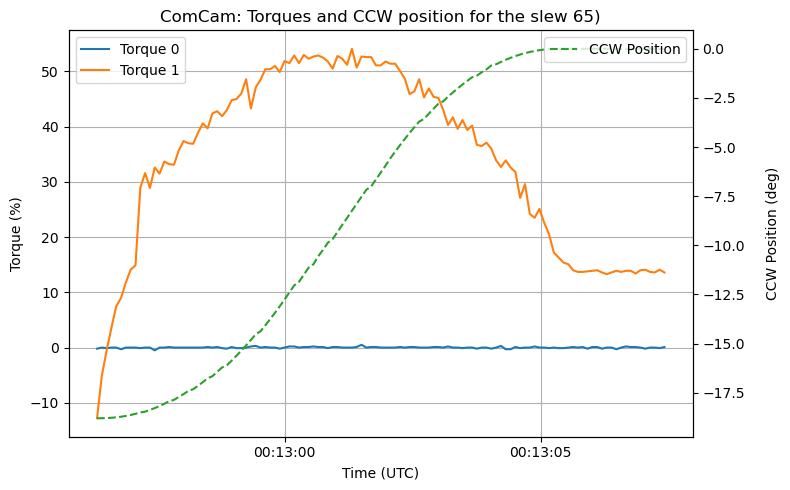

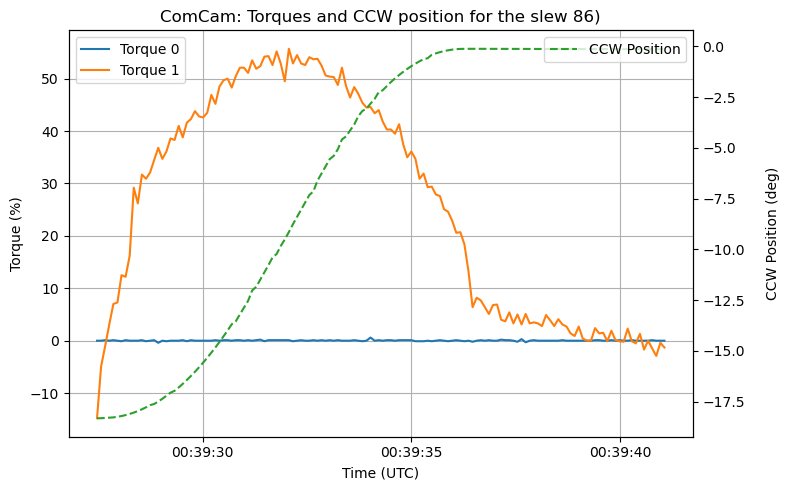

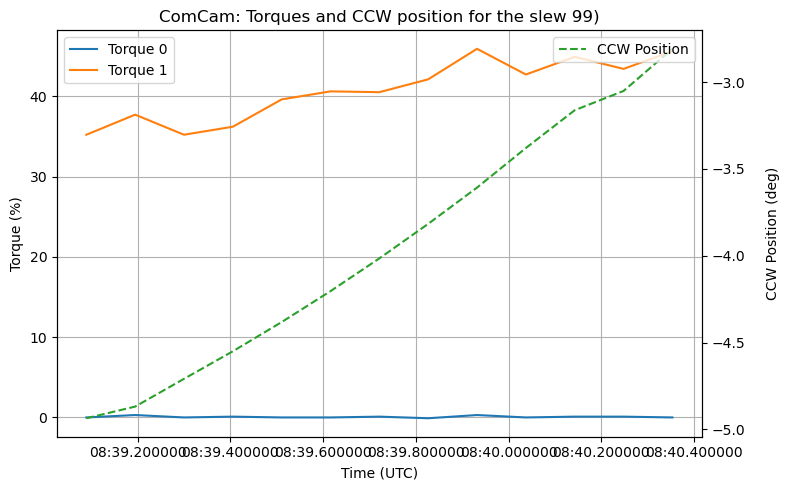

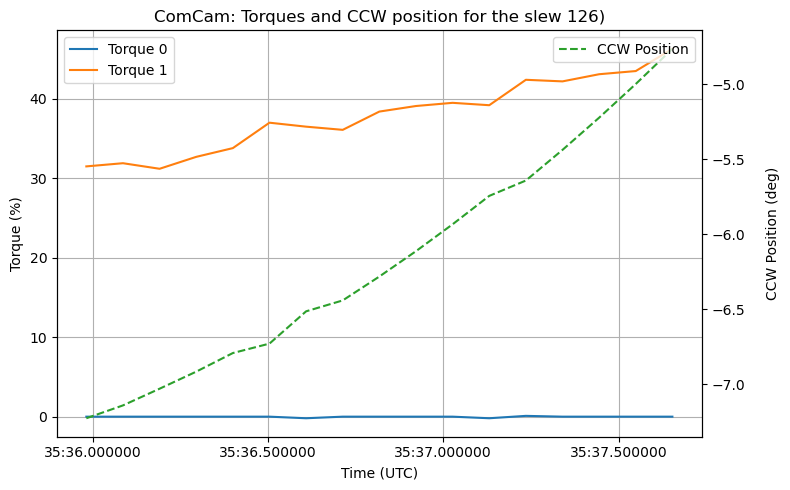

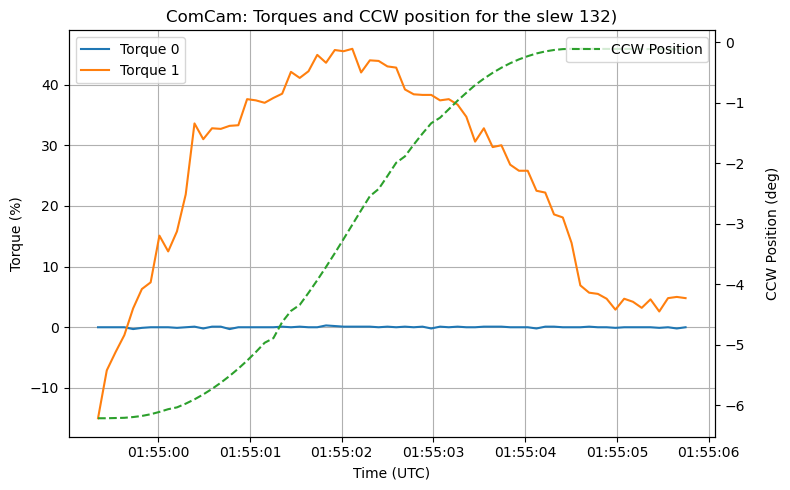

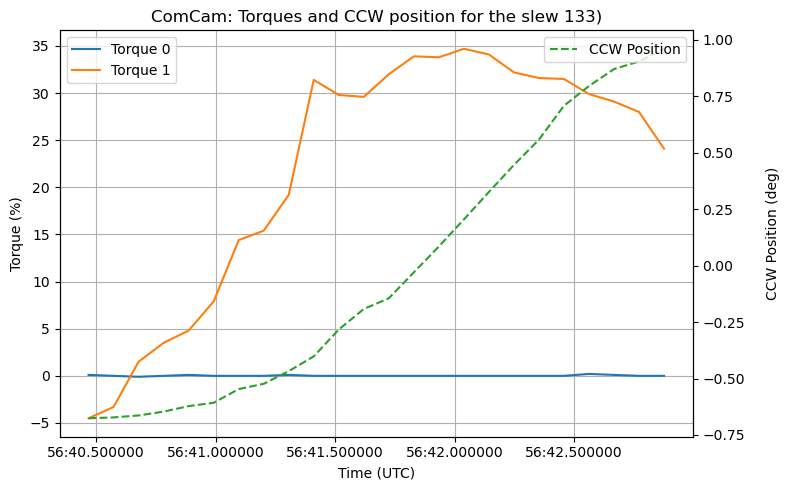

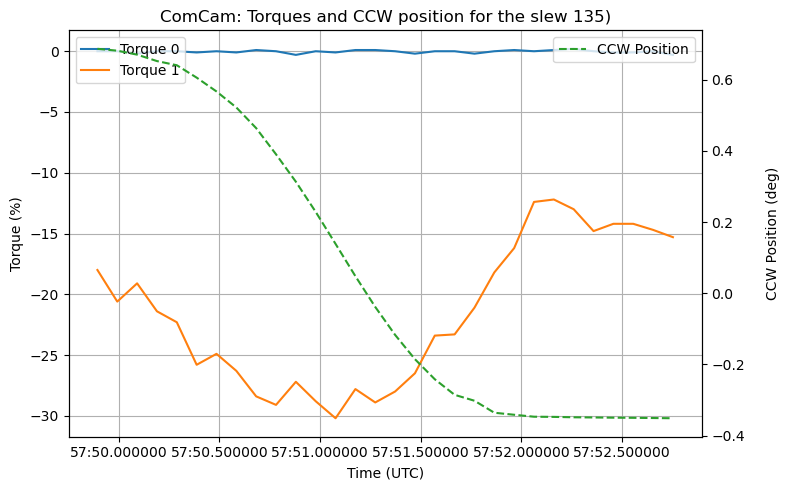

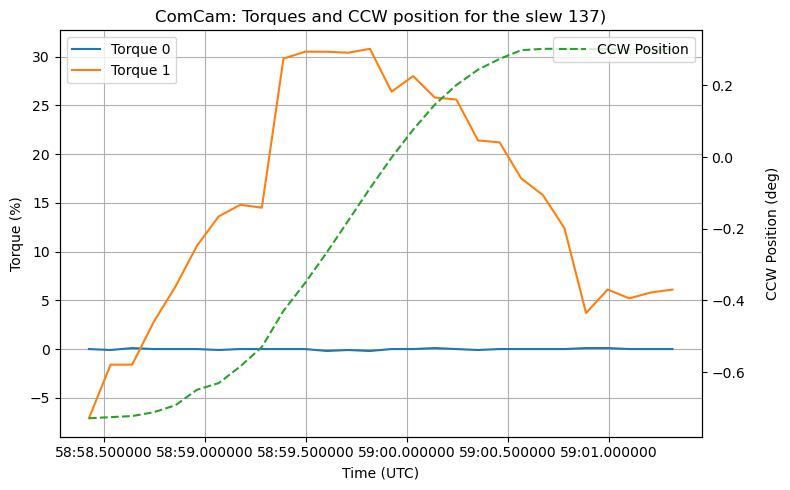

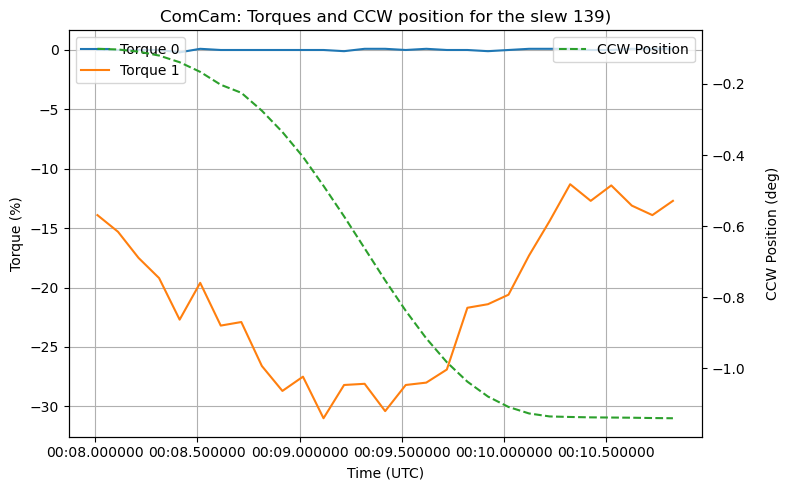

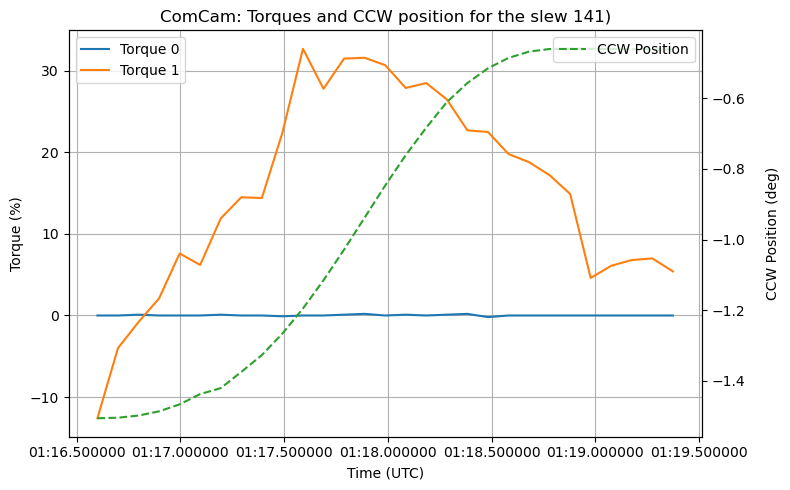

In [33]:
num_movements = min(10, len(movement_df))  

for i in range(num_movements):
    movement = movement_df.iloc[i]  
    
    fig, ax1 = plt.subplots(figsize=(8, 5))

    line1, = ax1.plot(movement["time"], movement["torque0"], color='C0', label="Torque 0")
    line2, = ax1.plot(movement["time"], movement["torque1"], color='C1', label="Torque 1")
    
    ax1.set_xlabel("Time (UTC)")
    ax1.set_ylabel("Torque (%)")
    ax1.tick_params(axis='y')

    ax2 = ax1.twinx()
    line3, = ax2.plot(movement["time"], movement["actualPosition"], color='C2', linestyle="--", label="Rotator Position")
    
    ax2.set_ylabel("CCW Position (deg)", labelpad=15)
    ax2.tick_params(axis='y')

    plt.title(f"ComCam: Torques and CCW position for the slew {movement['movement_id']})")
    
    ax1.legend(handles=[line1, line2], labels=["Torque 0", "Torque 1"], loc="upper left")
    ax2.legend(handles=[line3], labels=["CCW Position"], loc="upper right")
    
    ax1.grid()
    plt.tight_layout()

    plt.show()


Lets remove the bias, calculate the area under the torque curve and add it to dataframe

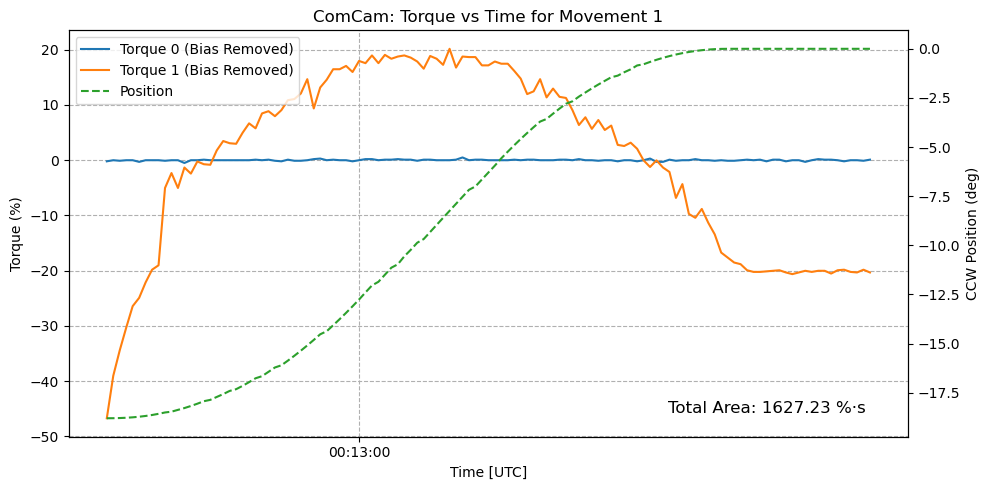

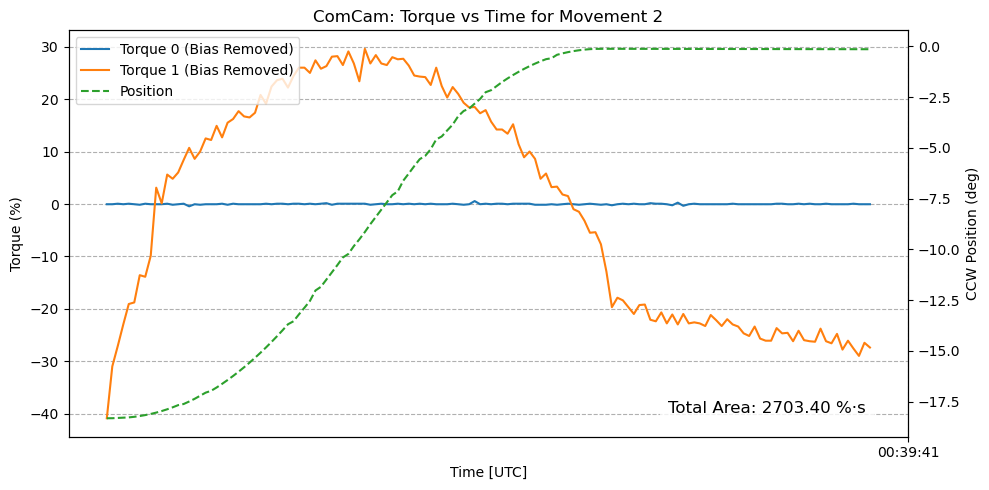

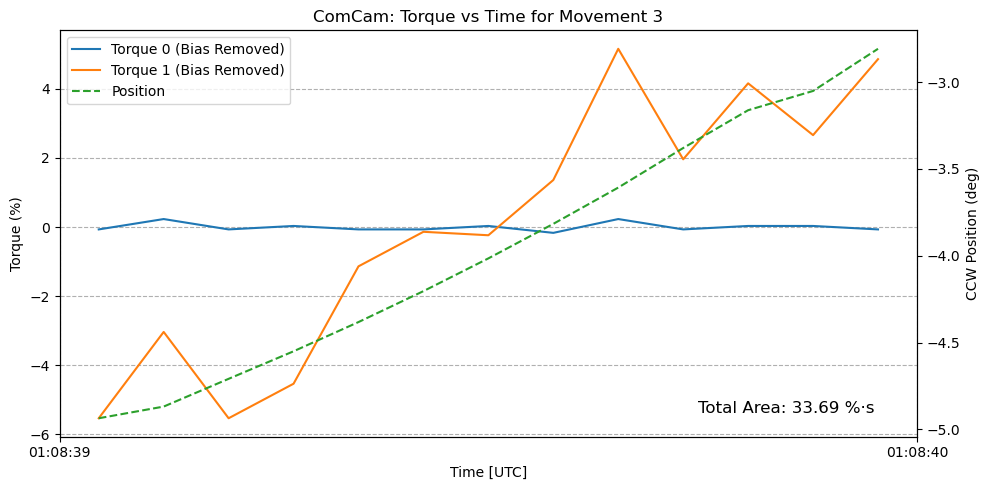

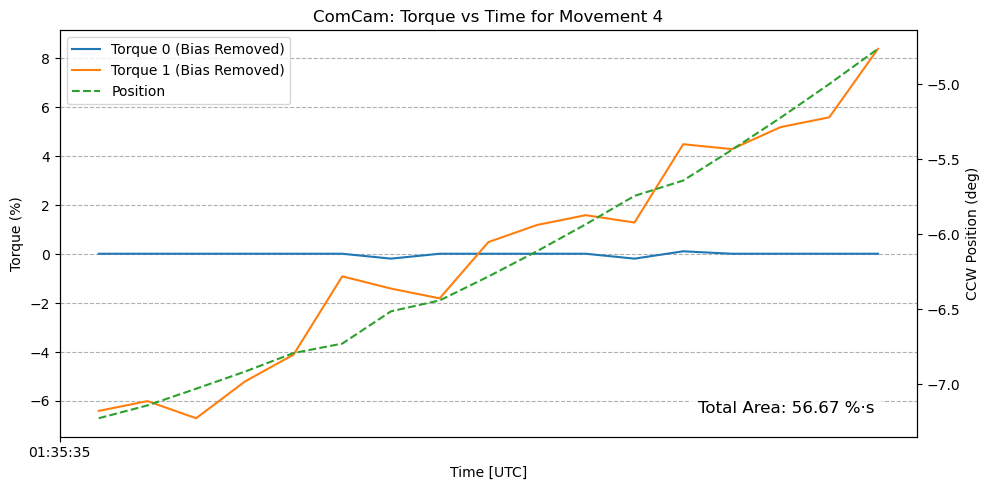

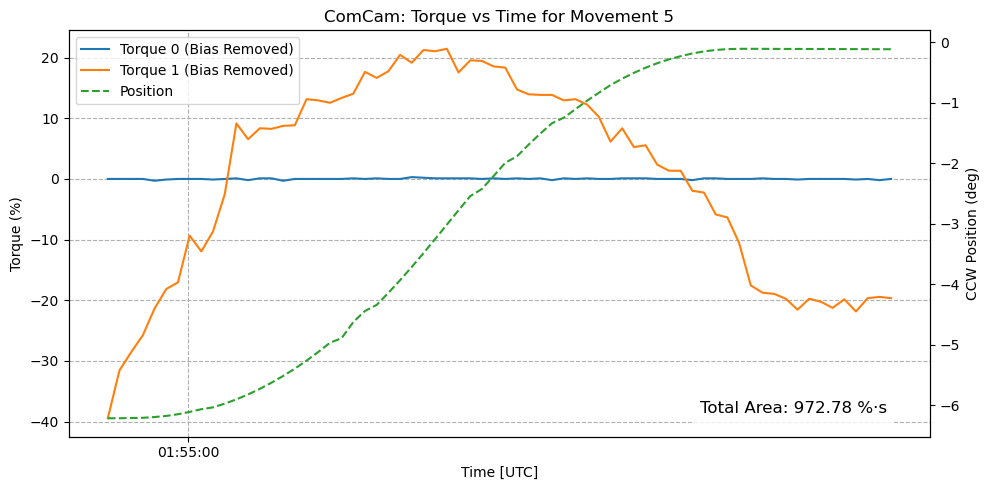

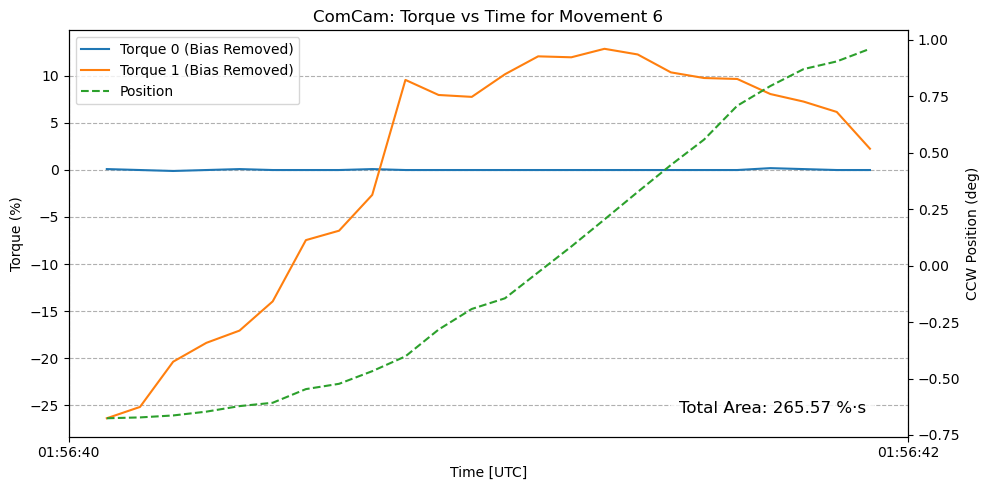

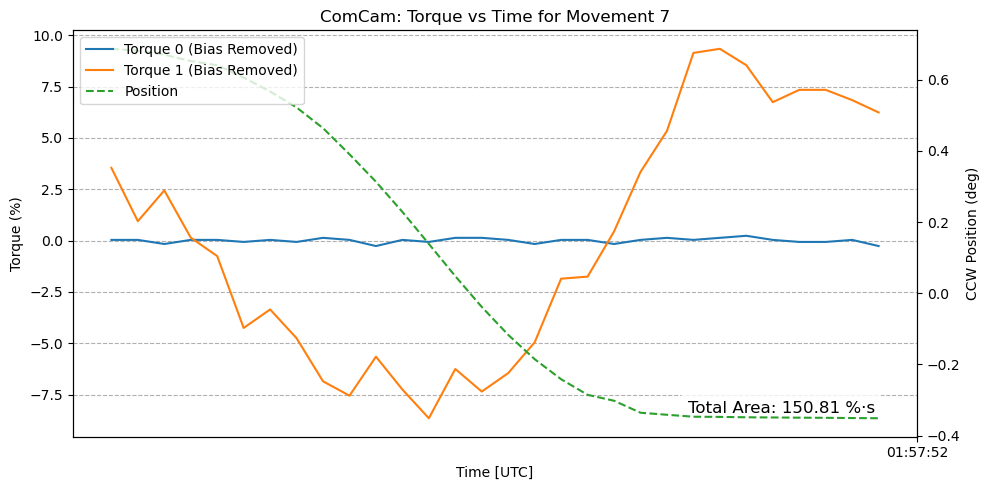

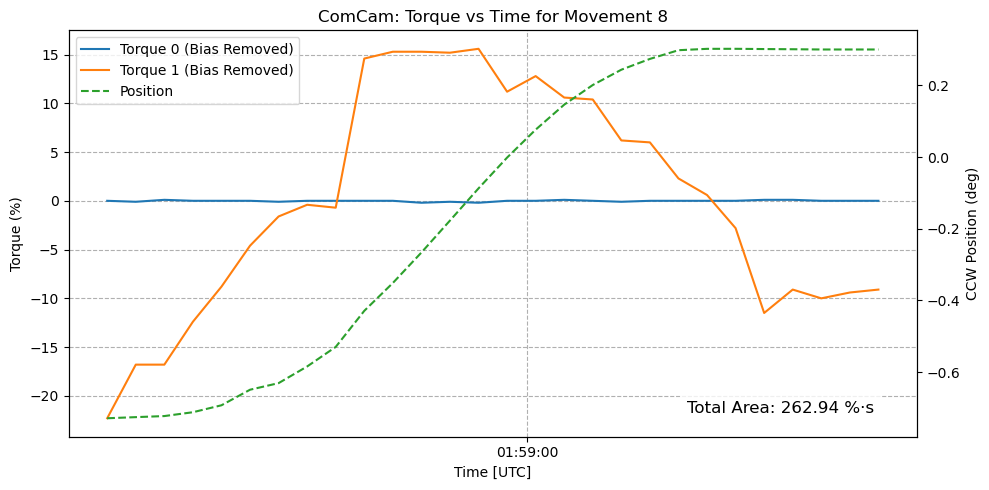

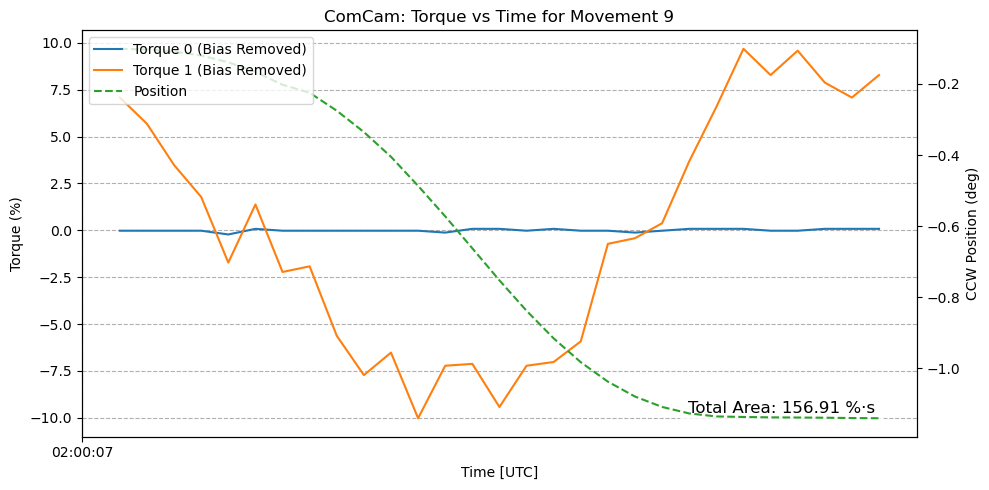

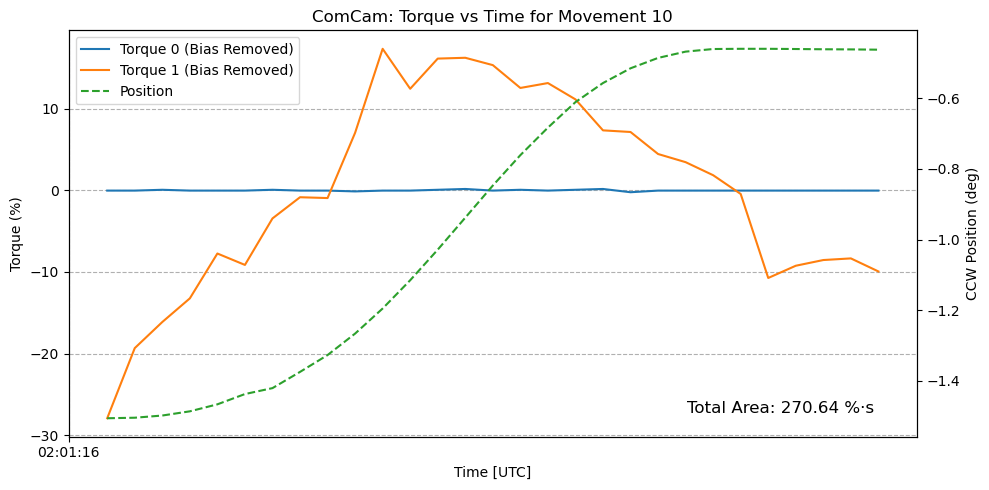

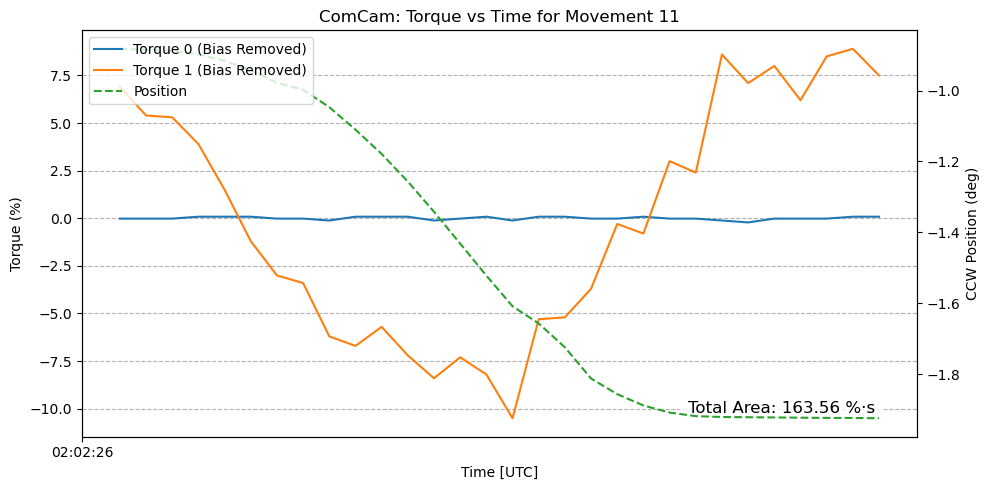

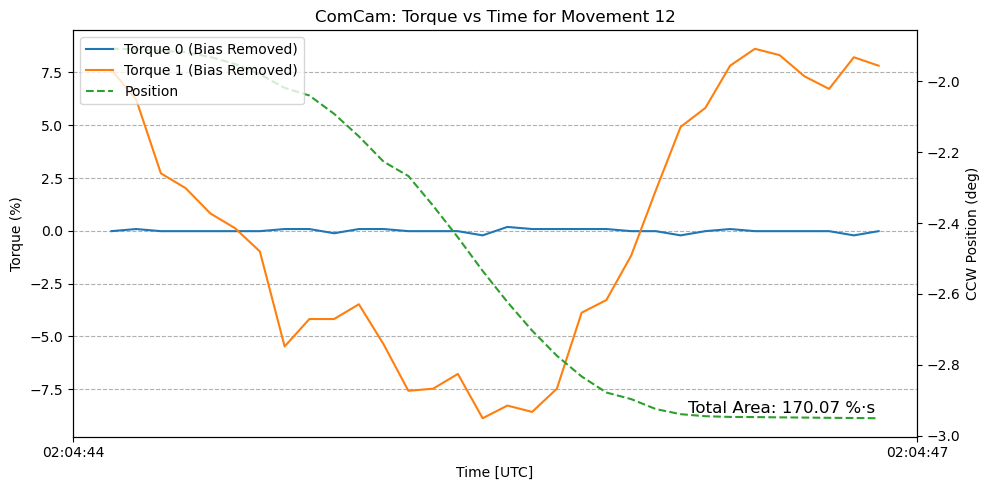

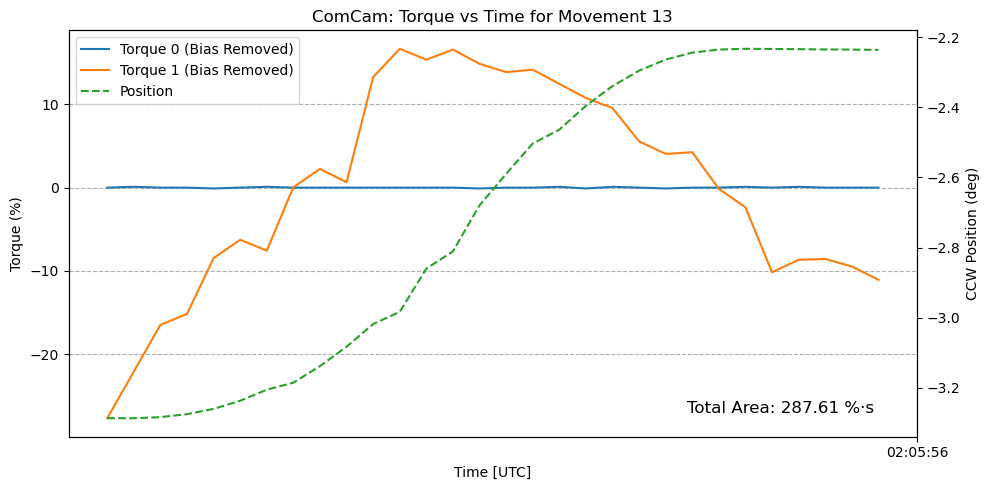

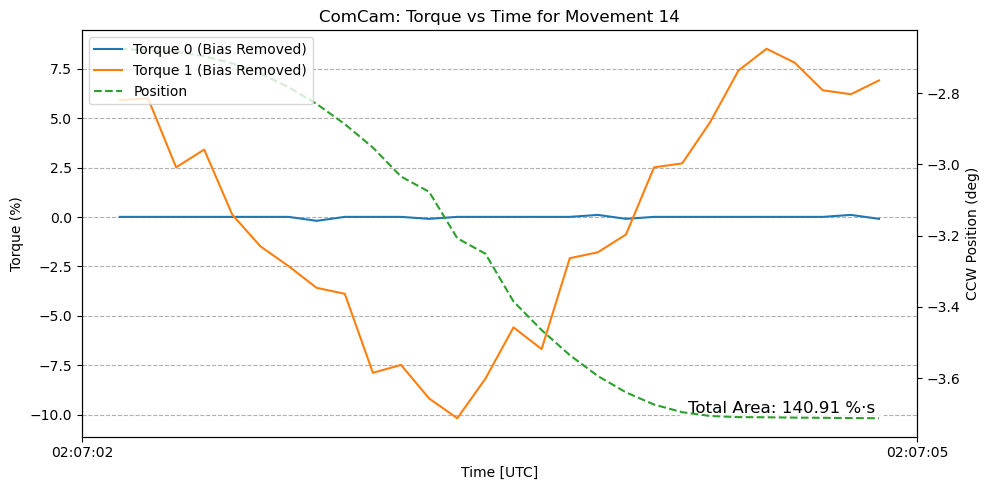

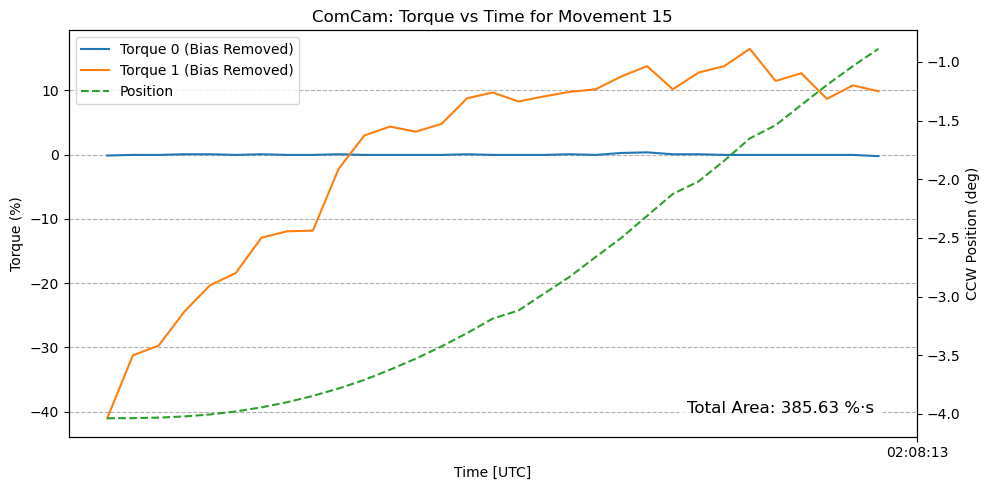

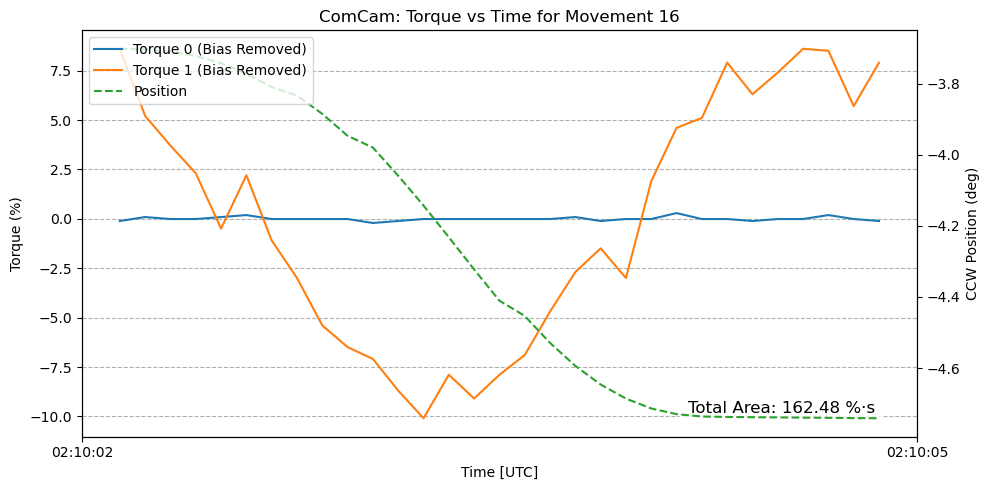

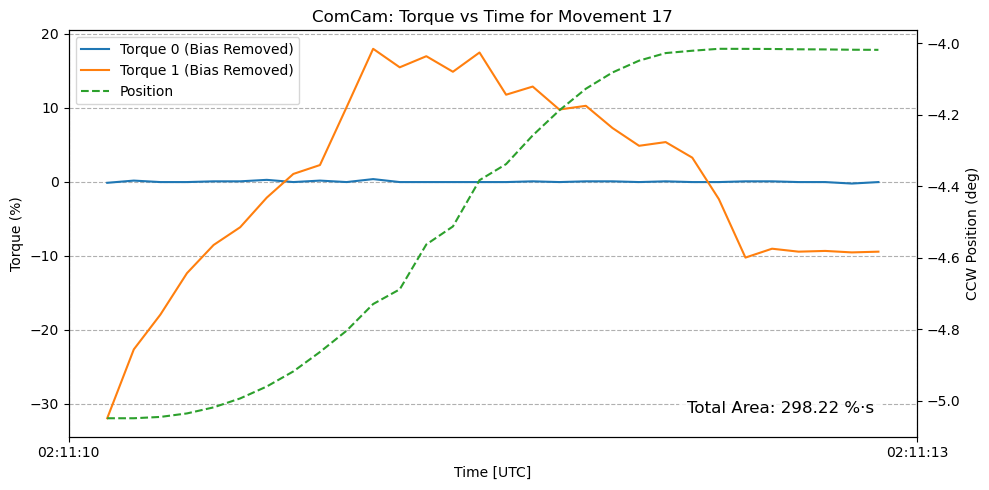

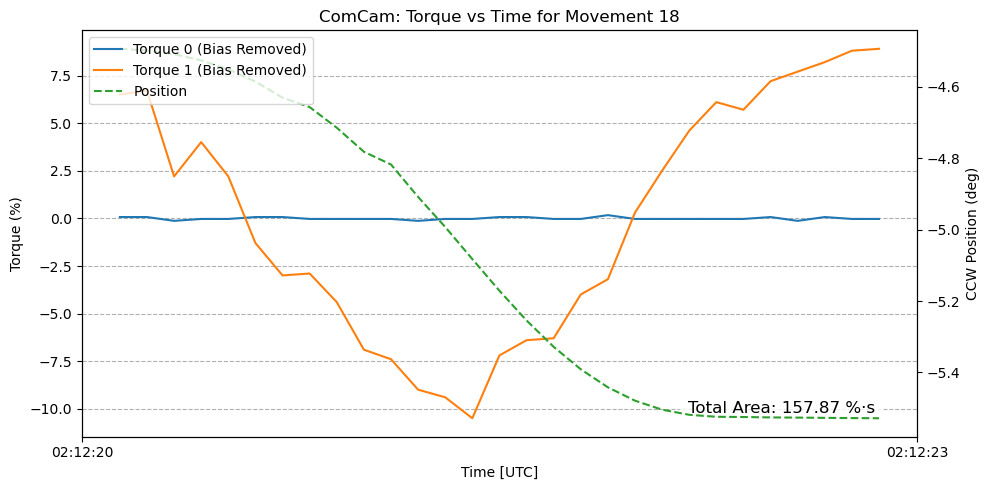

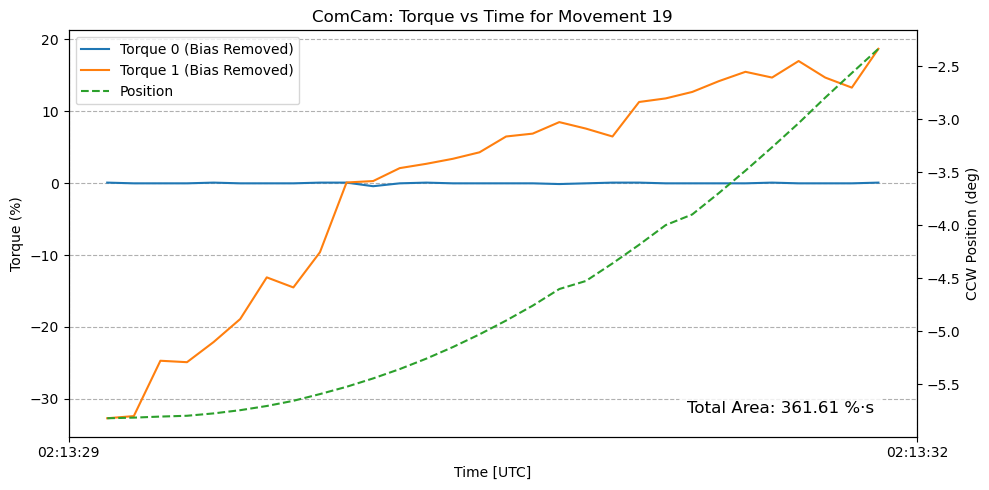

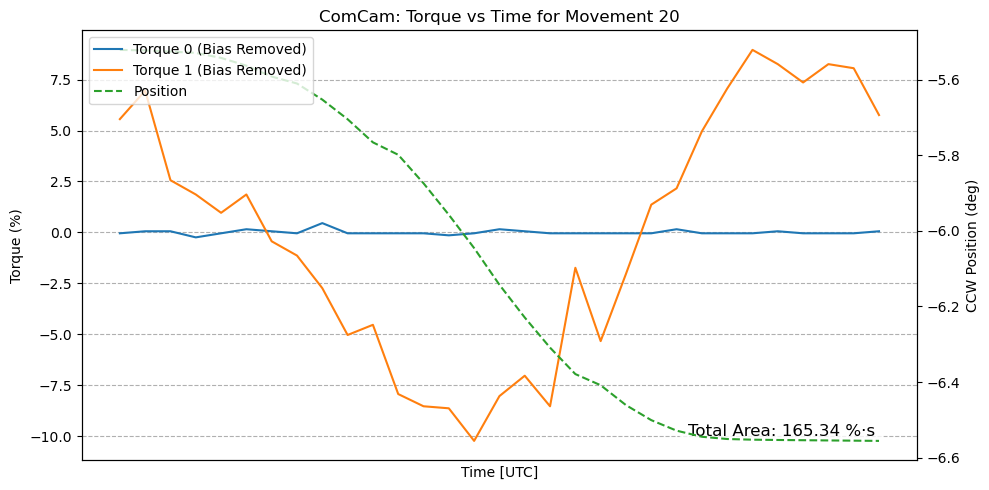

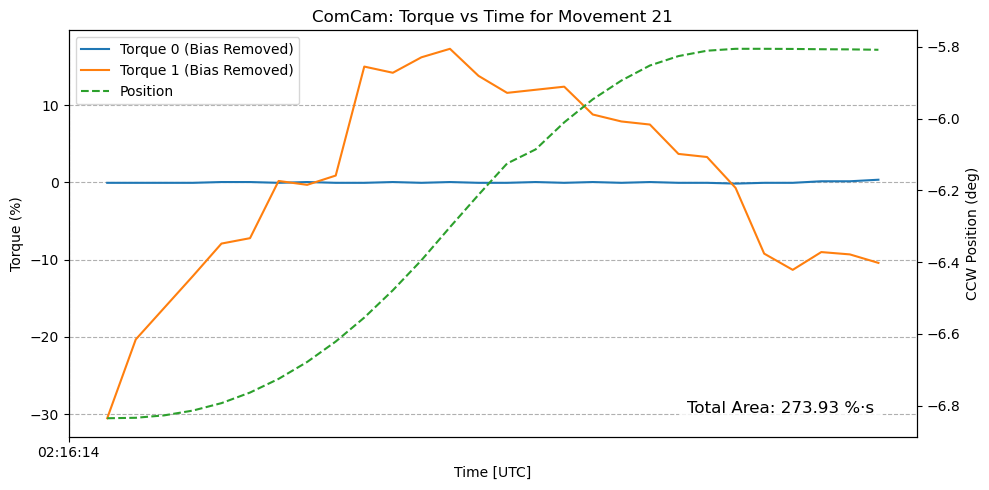

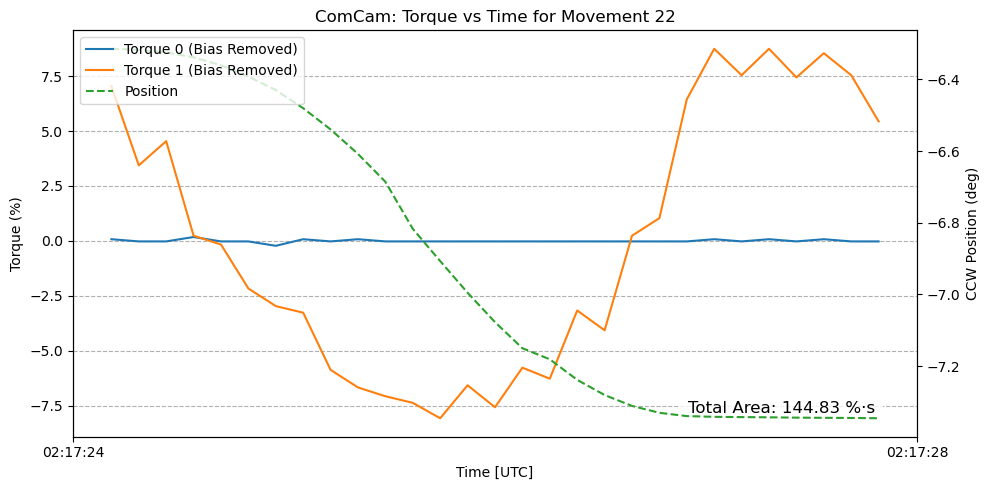

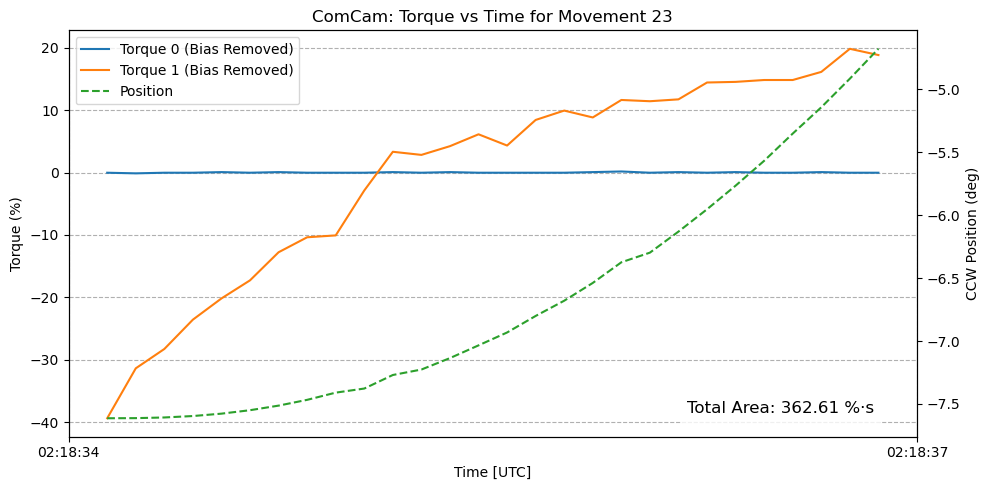

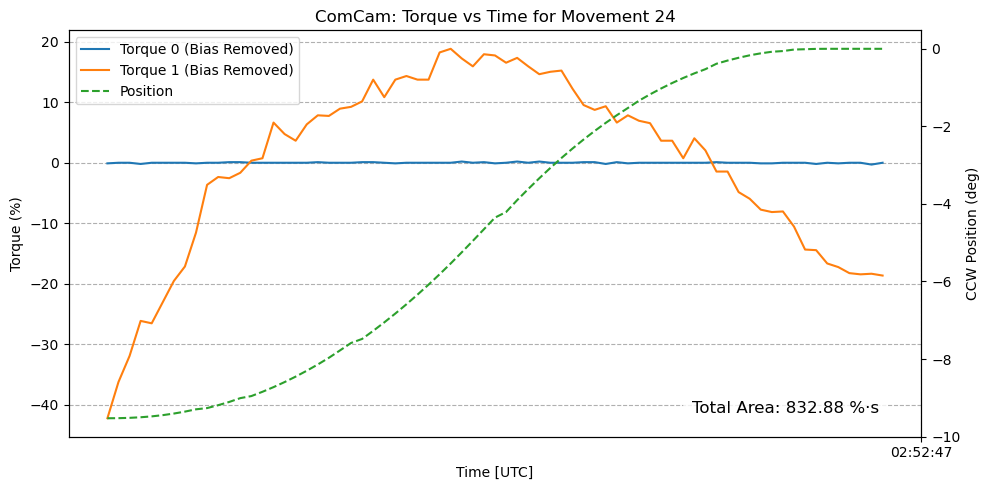

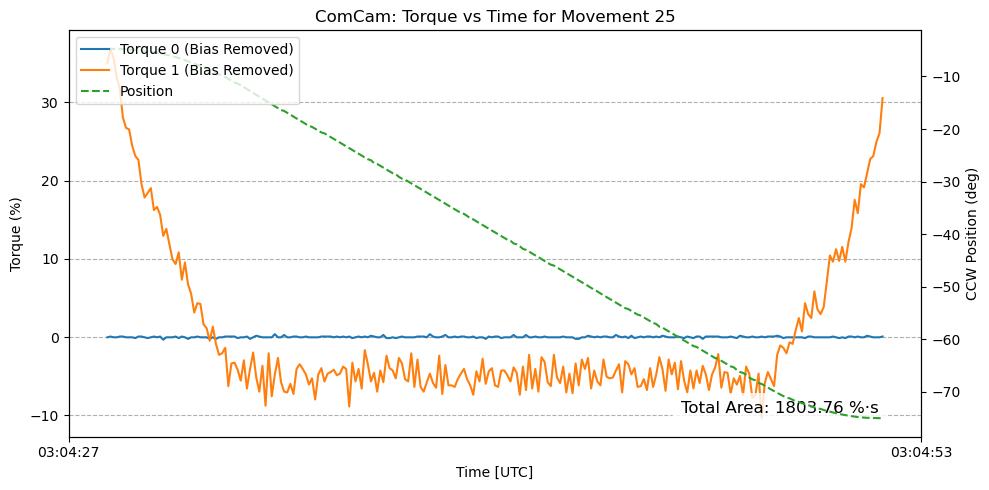

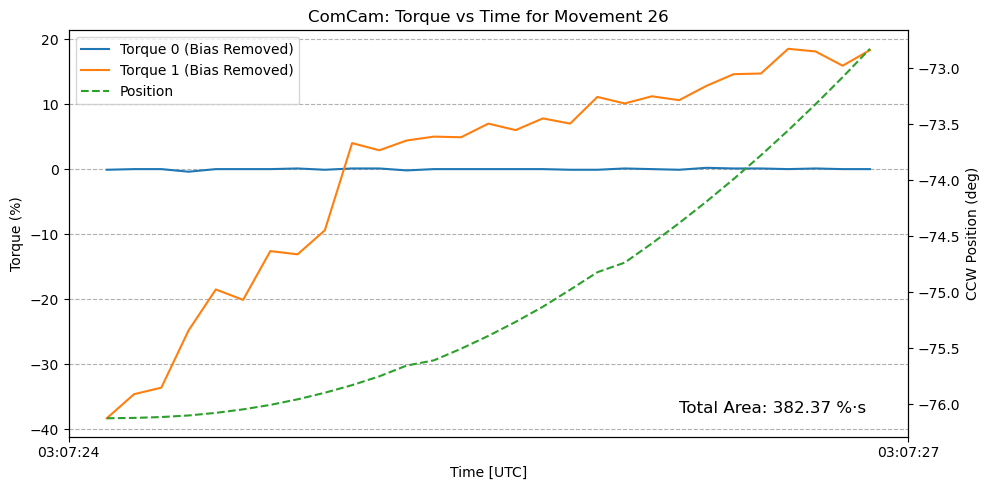

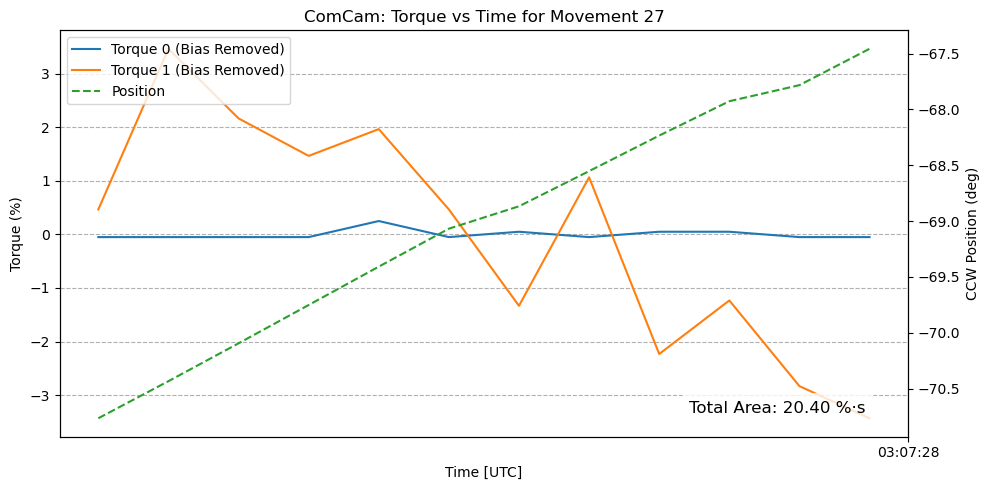

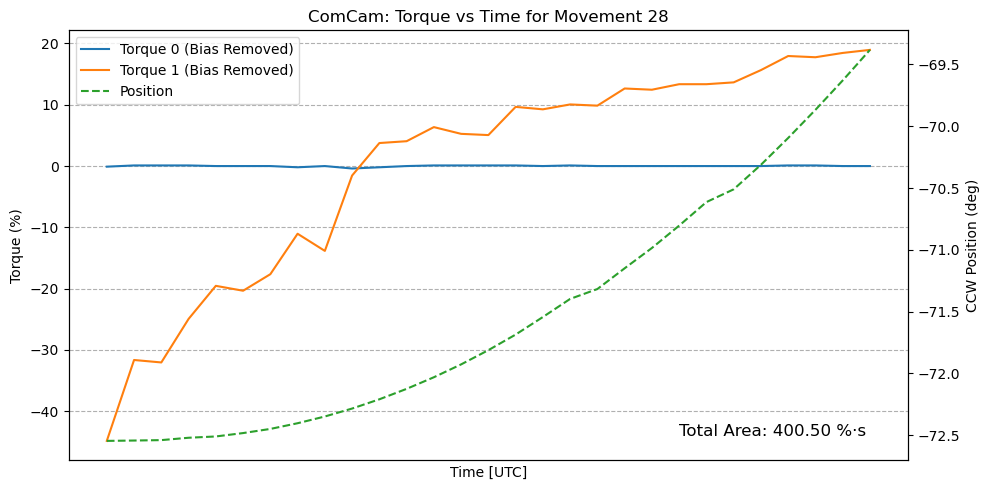

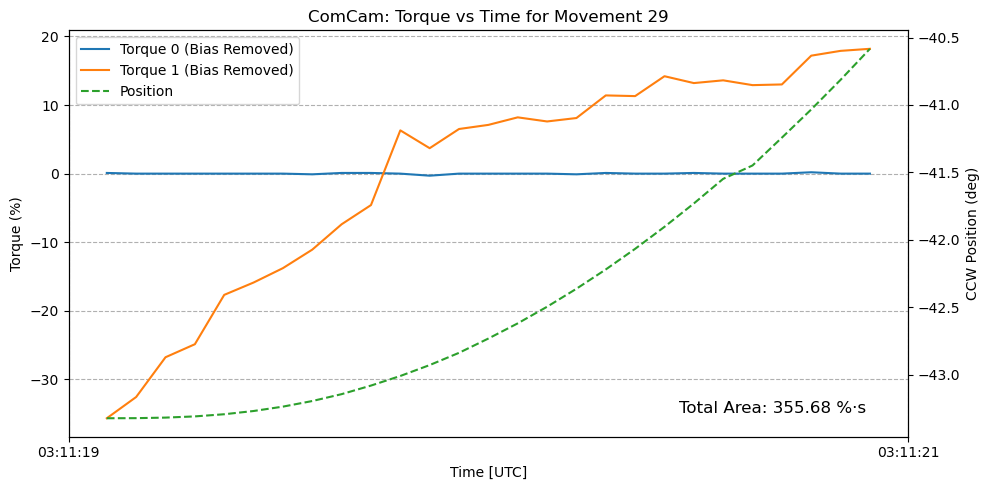

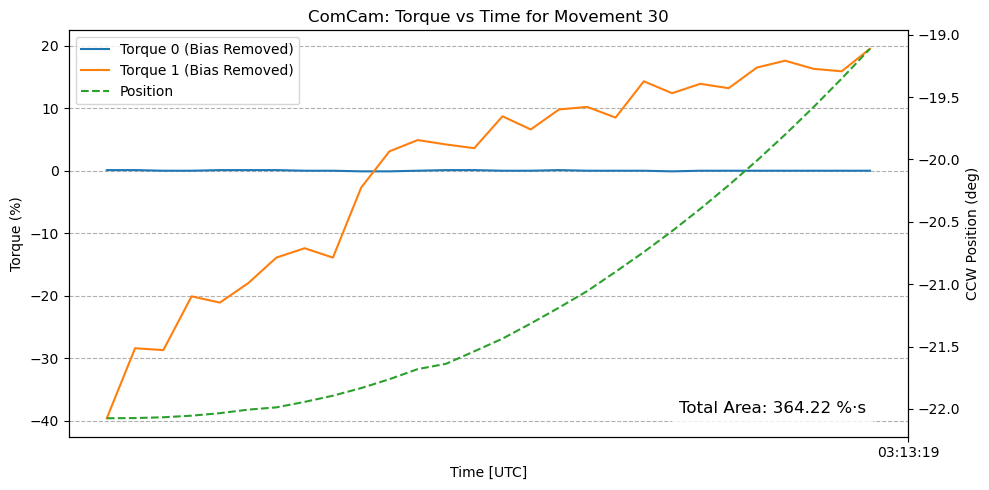

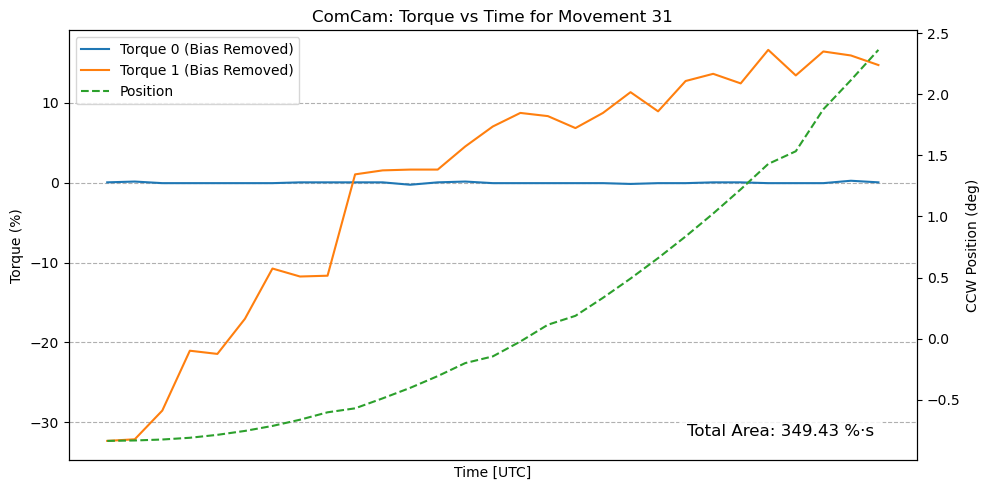

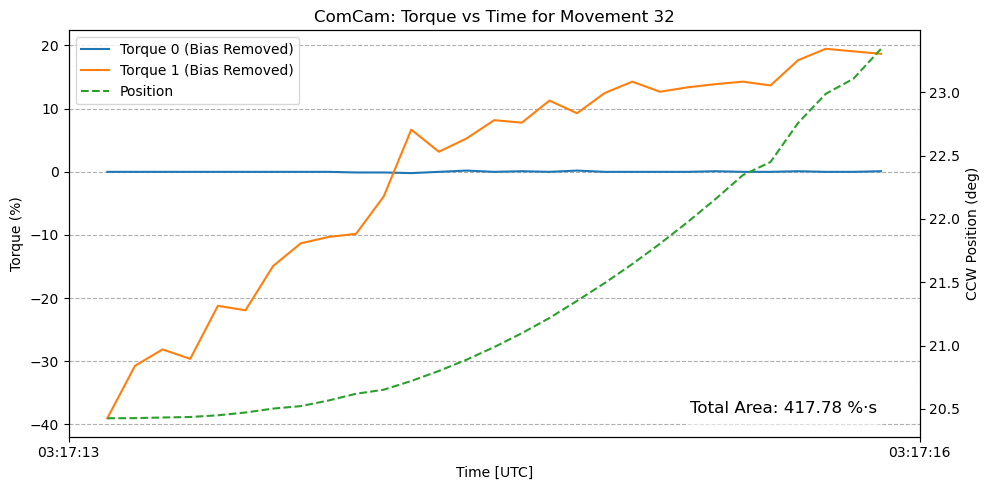

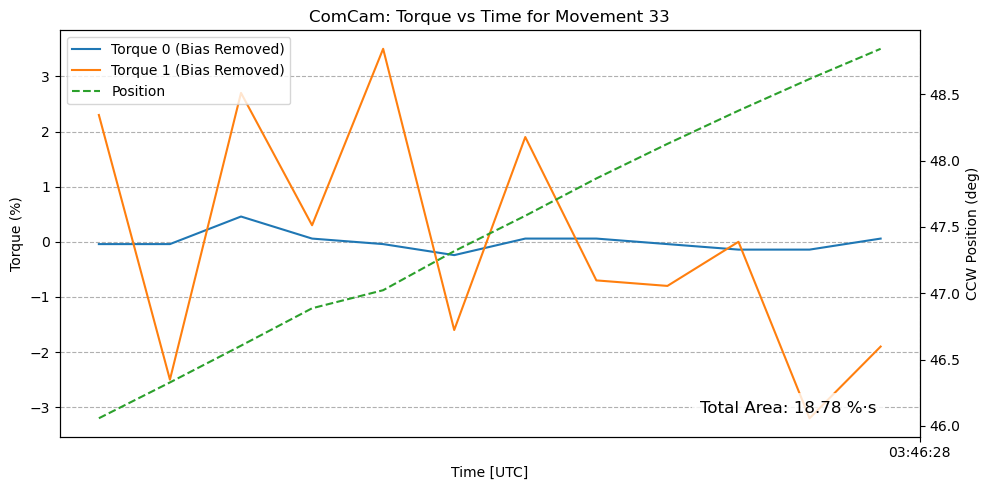

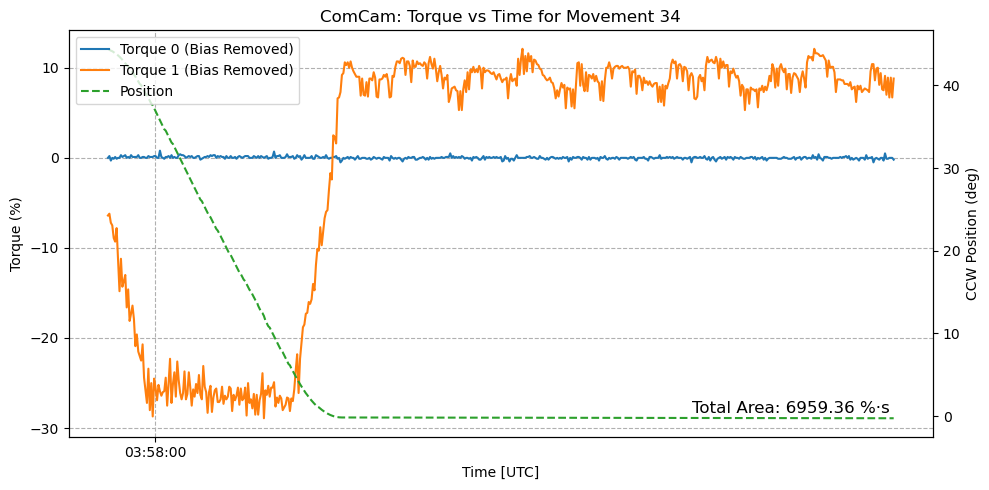

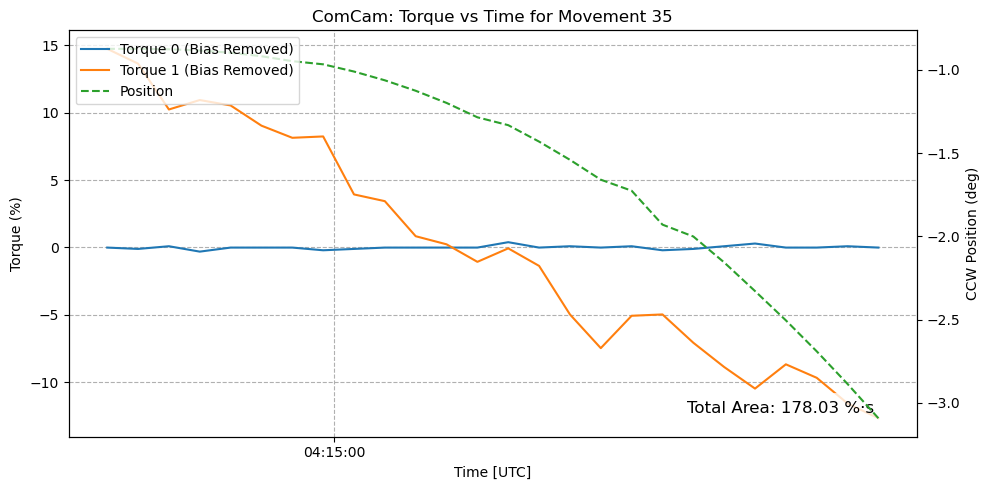

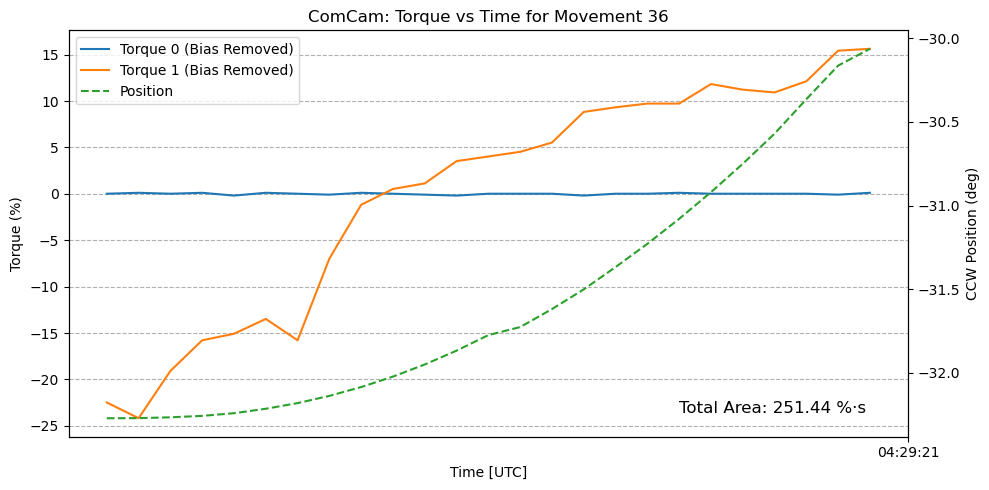

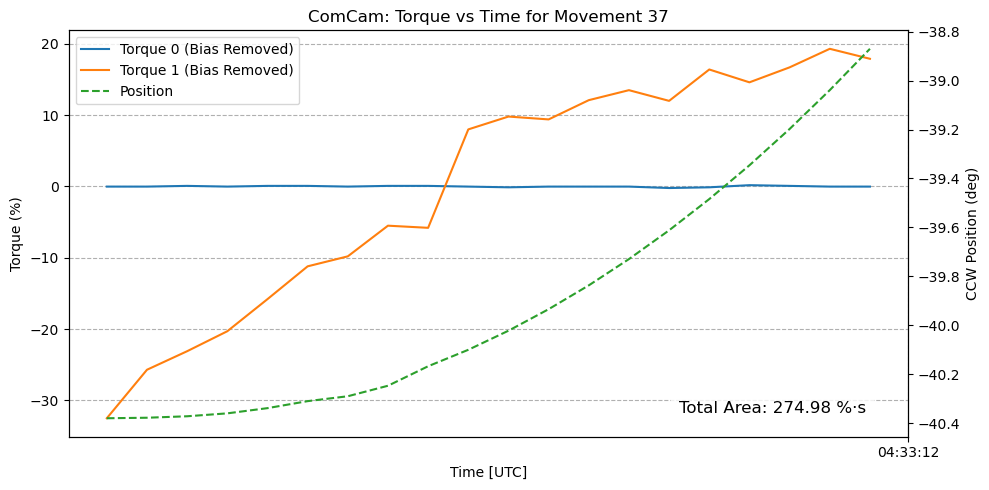

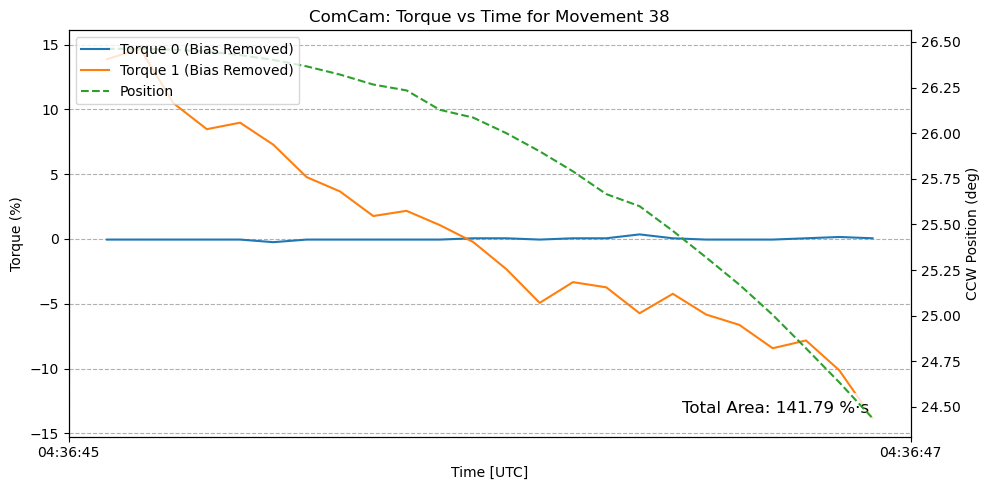

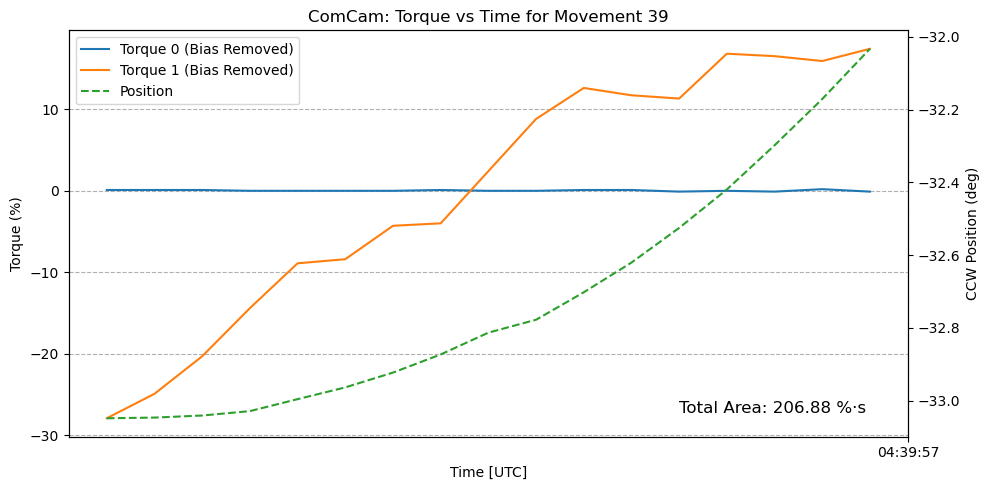

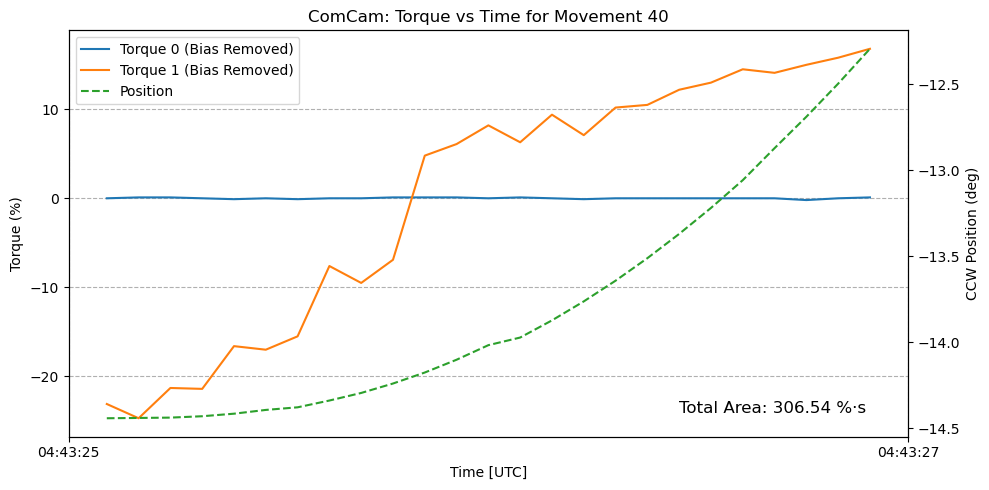

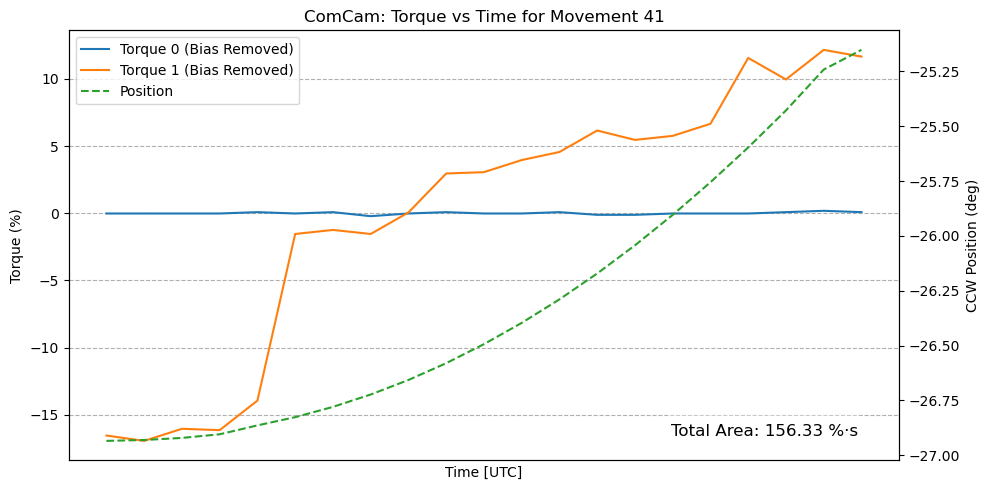

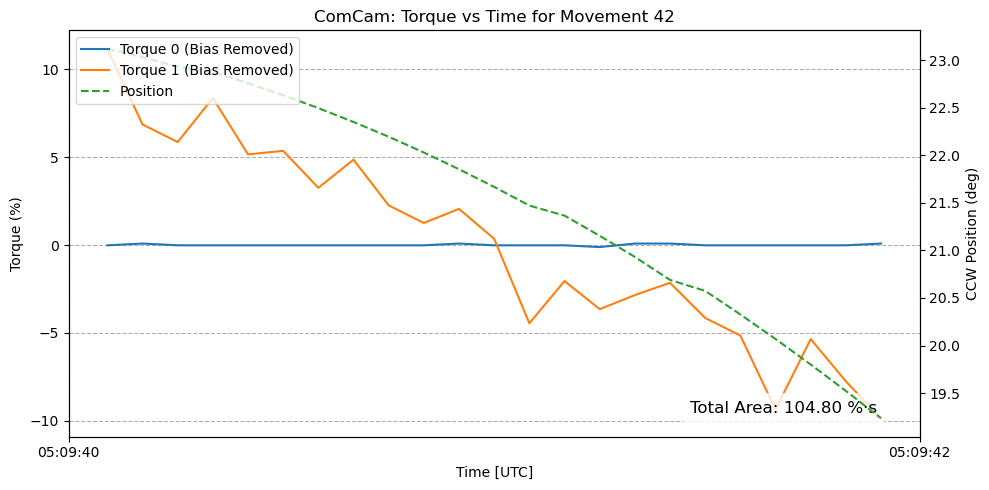

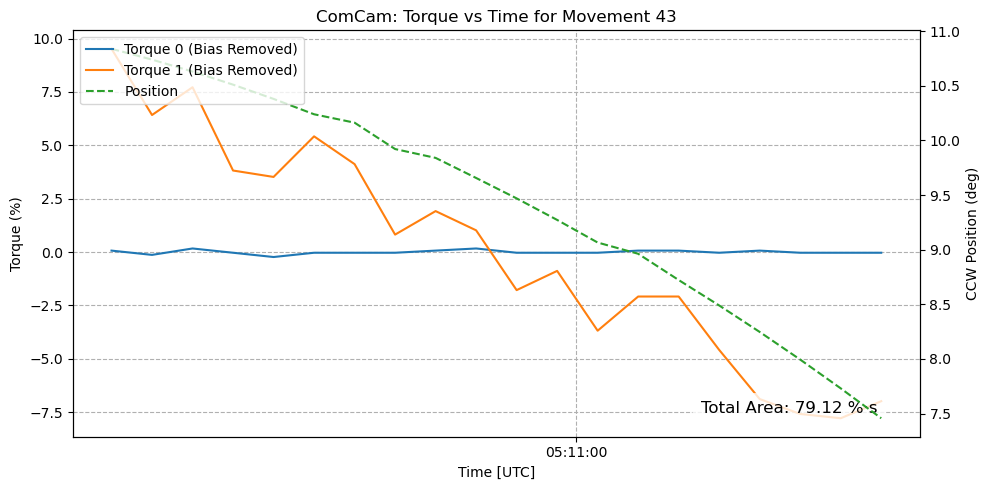

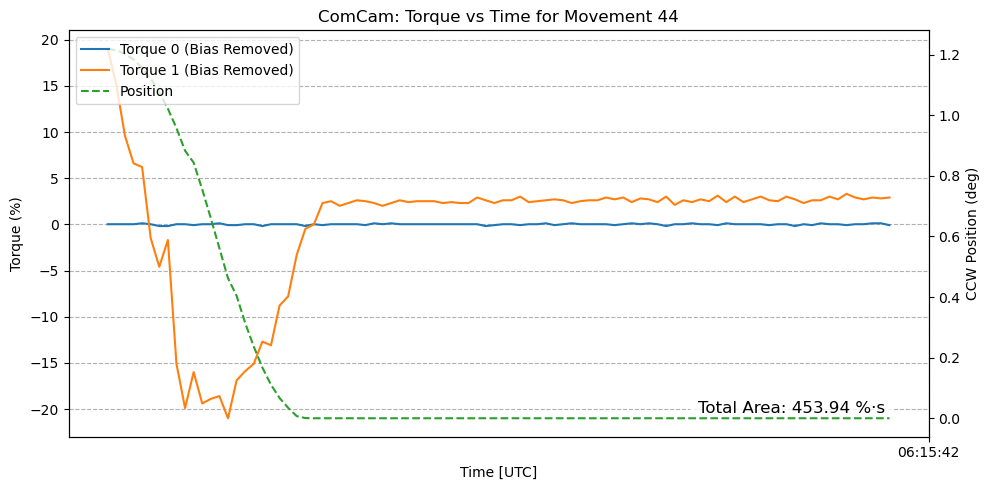

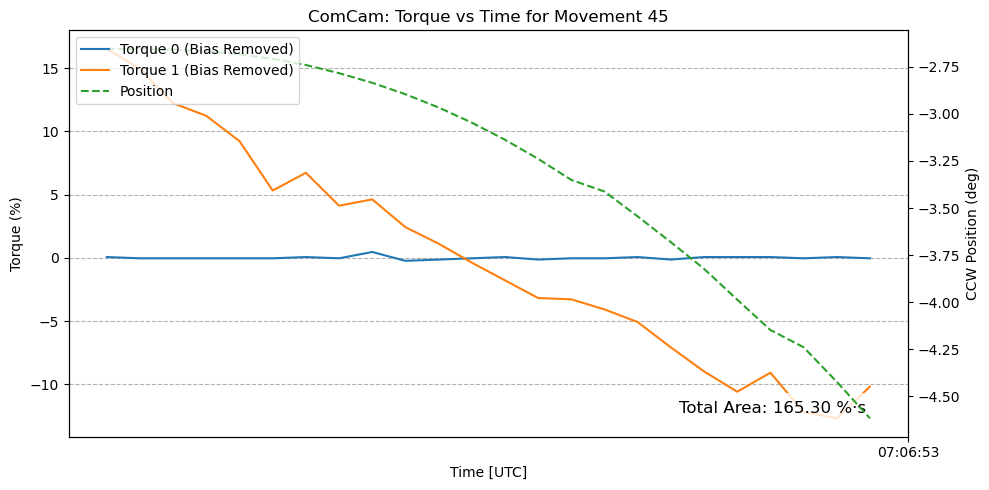

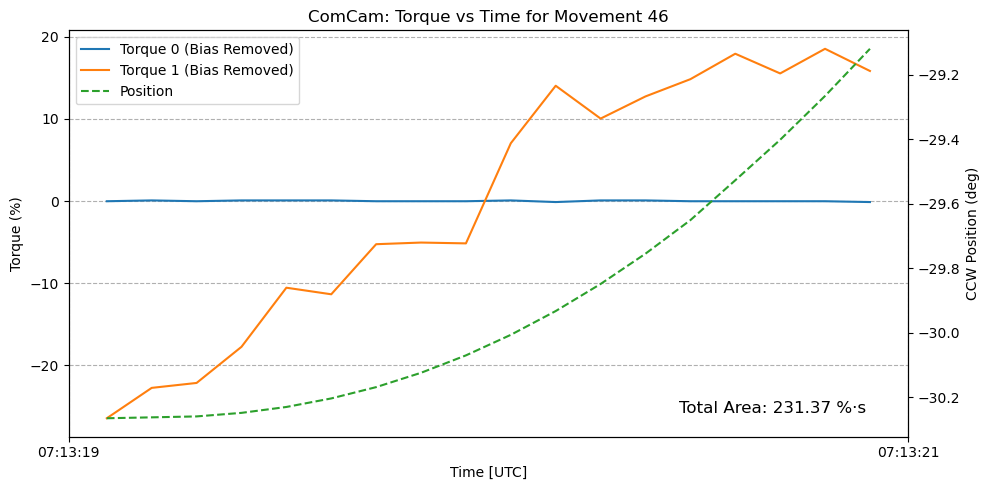

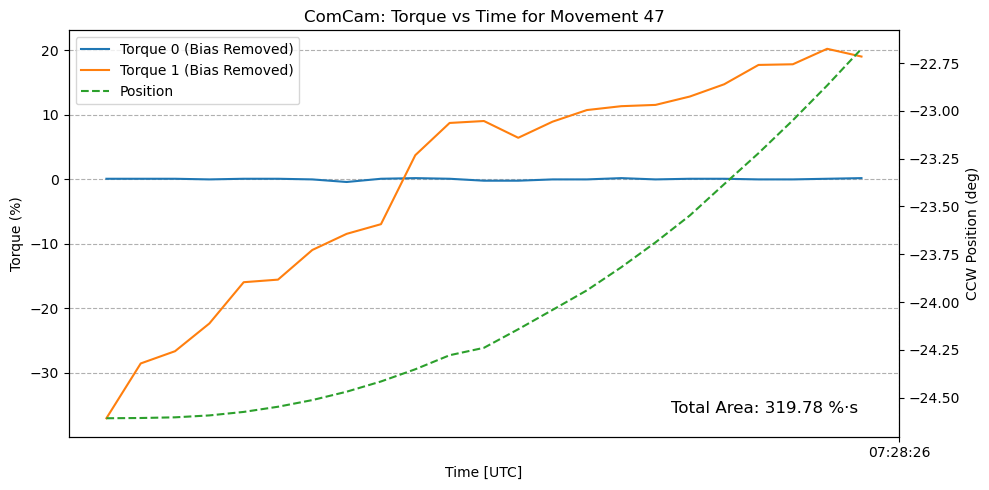

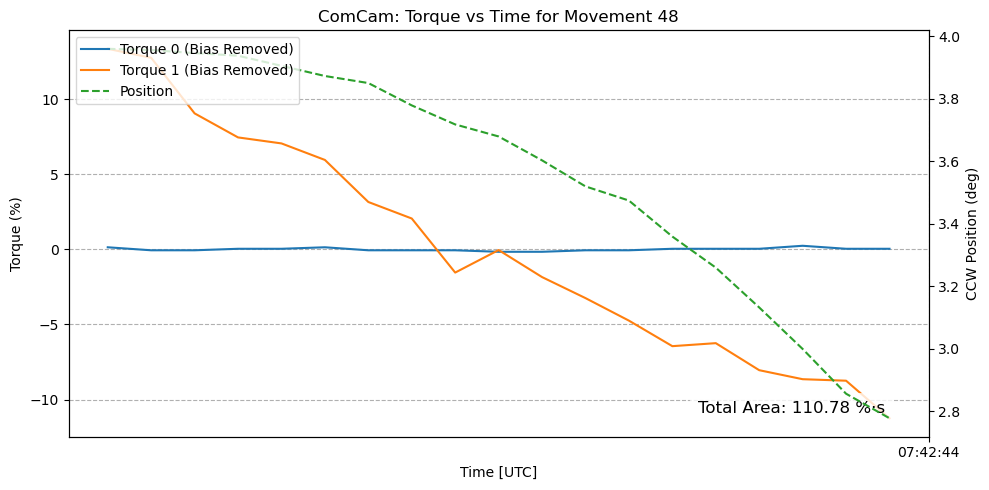

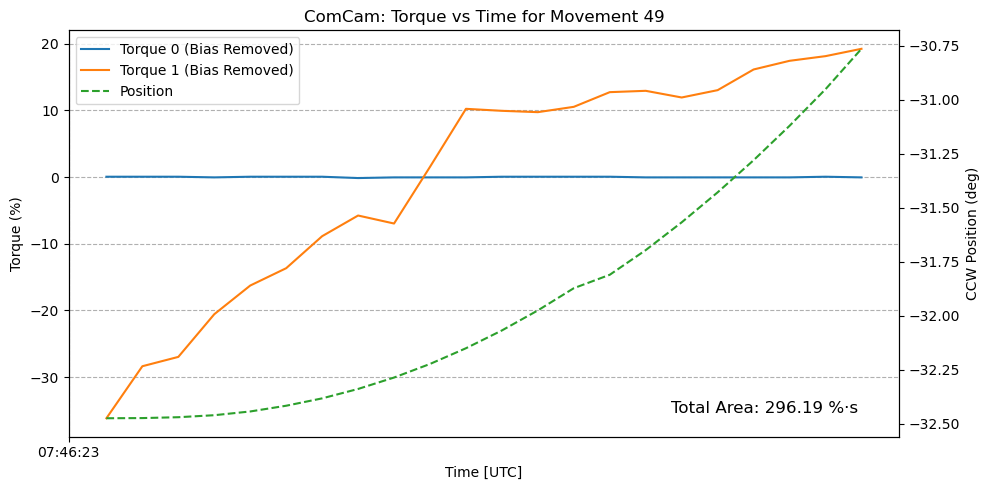

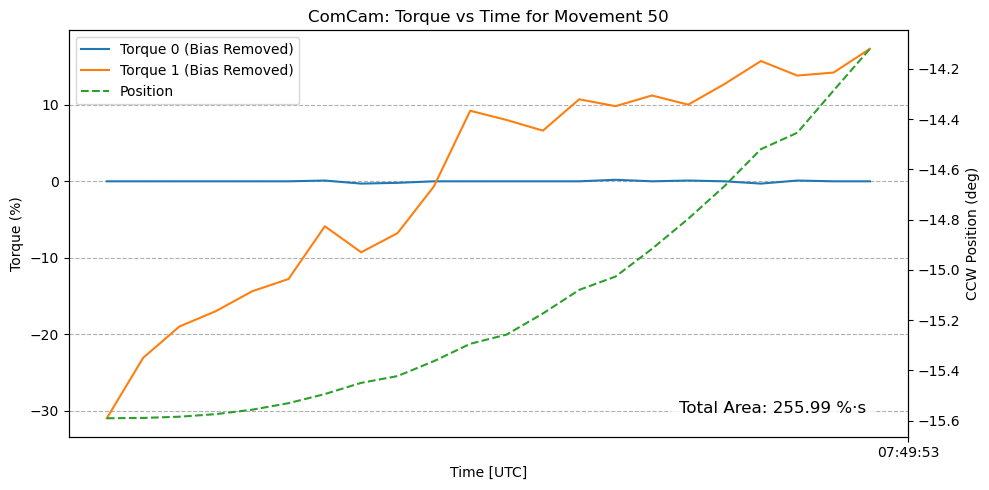

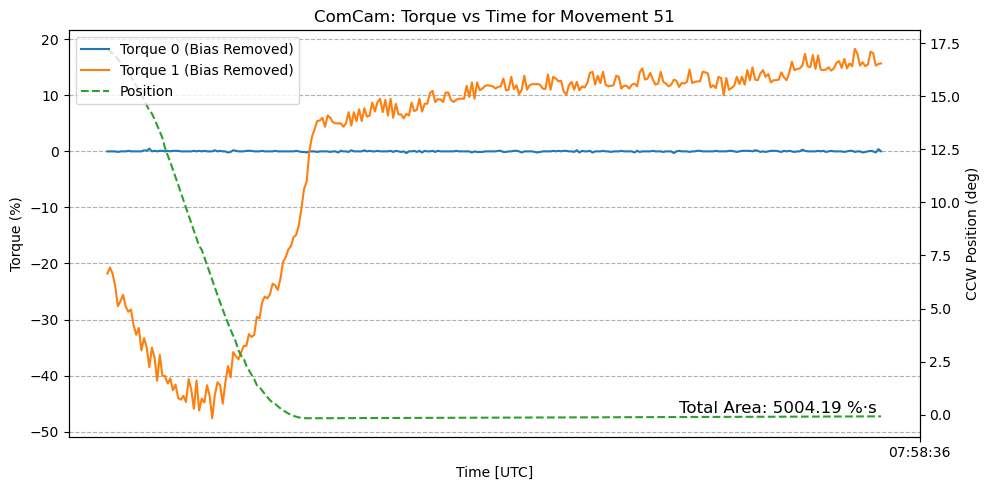

In [35]:
if len(movement_df) > 0:
    areas = []  

    for i, row in movement_df.iterrows():
        time = row["time"]
        torque0 = row["torque0"]
        torque1 = row["torque1"]
        position = row["actualPosition"]

        torque0 -= np.mean(torque0)
        torque1 -= np.mean(torque1)

        area_torque0 = simpson(np.abs(torque0), dx=1)  
        area_torque1 = simpson(np.abs(torque1), dx=1)  

        total_area = area_torque0 + area_torque1  
        areas.append(total_area)  

        fig, ax = plt.subplots(figsize=(10, 5))

        ax.plot(time, torque0, color="C0", label="Torque 0 (Bias Removed)")
        ax.plot(time, torque1, color="C1", label="Torque 1 (Bias Removed)")

        ax.set_xlabel("Time [UTC]")
        ax.set_ylabel("Torque (%)")
        ax.set_title(f"ComCam: Torque vs Time for Movement {i + 1}")

        ax2 = ax.twinx()
        ax2.plot(time, position, color="C2", label="Position", linestyle="--")
        ax2.set_ylabel("CCW Position (deg)")

        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
        ax.xaxis.set_major_locator(mdates.MinuteLocator())

        handles, labels = ax.get_legend_handles_labels()
        handles2, labels2 = ax2.get_legend_handles_labels()
        ax2.legend(handles + handles2, labels + labels2, loc="upper left")

        ax.grid(which="major", axis="both", linestyle="--")
        
        area_text = f"Total Area: {total_area:.2f} %·s"
        ax.text(0.95, 0.05, area_text, transform=ax.transAxes,
                ha="right", va="bottom", fontsize=12, color="black",
                bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", boxstyle="round,pad=0.5"))

        plt.tight_layout()
        plt.show()
        plt.close(fig)

    movement_df["area (% s)"] = areas

else:
    print("No valid movement pairs found.")


Let's calculate the movement size according to the ccw position 

In [36]:
movement_sizes = []

for i, row in movement_df.iterrows():
    position = row['actualPosition']
    
    movement_size = np.abs(position.max() - position.min())
    movement_sizes.append(movement_size)

movement_df['movement_size (degrees)'] = movement_sizes

print(movement_df[['movement_size (degrees)']])


    movement_size (degrees)
0                 18.803499
1                 18.203299
2                  2.127400
3                  2.462500
4                  6.109900
5                  1.636900
6                  1.038300
7                  1.030800
8                  1.039800
9                  1.046000
10                 1.042600
11                 1.043200
12                 1.055300
13                 1.038200
14                 3.148800
15                 1.039300
16                 1.032100
17                 1.035000
18                 3.488200
19                 1.034700
20                 1.029200
21                 1.030900
22                 2.933800
23                 9.527300
24                70.256703
25                 3.301094
26                 3.309700
27                 3.163498
28                 2.739700
29                 2.961399
30                 3.202500
31                 2.919300
32                 2.786098
33                44.679099
34                 2

Let's plot the area VS movement size

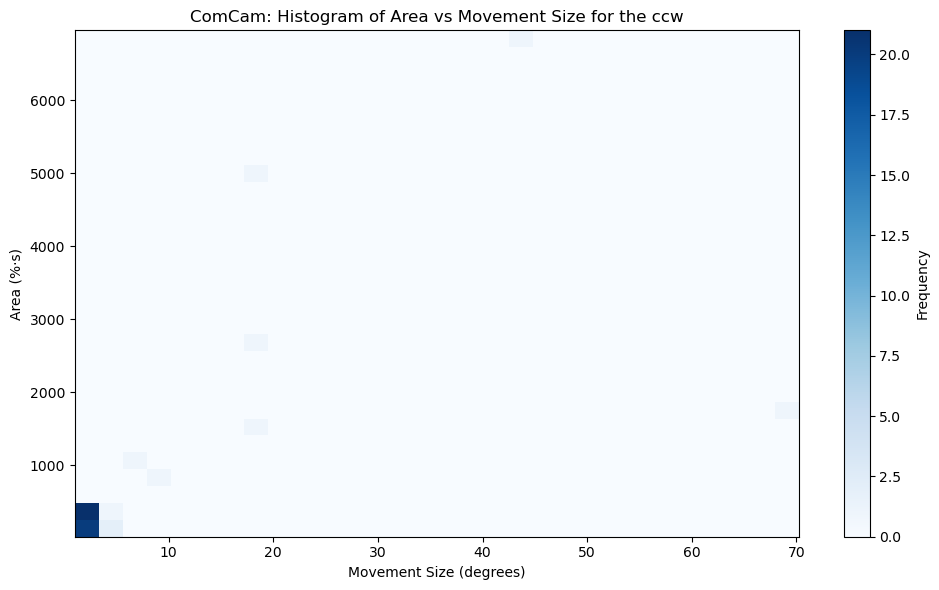

In [40]:
if 'area (% s)' in movement_df.columns and 'movement_size (degrees)' in movement_df.columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.hist2d(movement_df['movement_size (degrees)'], movement_df['area (% s)'], bins=30, cmap='Blues')
    
    ax.set_xlabel('Movement Size (degrees)')
    ax.set_ylabel('Area (%·s)')
    ax.set_title('ComCam: Histogram of Area vs Movement Size for the ccw')
    
    cbar = plt.colorbar(ax.collections[0], ax=ax)
    cbar.set_label('Frequency')
    
    plt.tight_layout()
    plt.show()
else:
    print("Required columns not found in the DataFrame.")


Let's try to add some linear fit

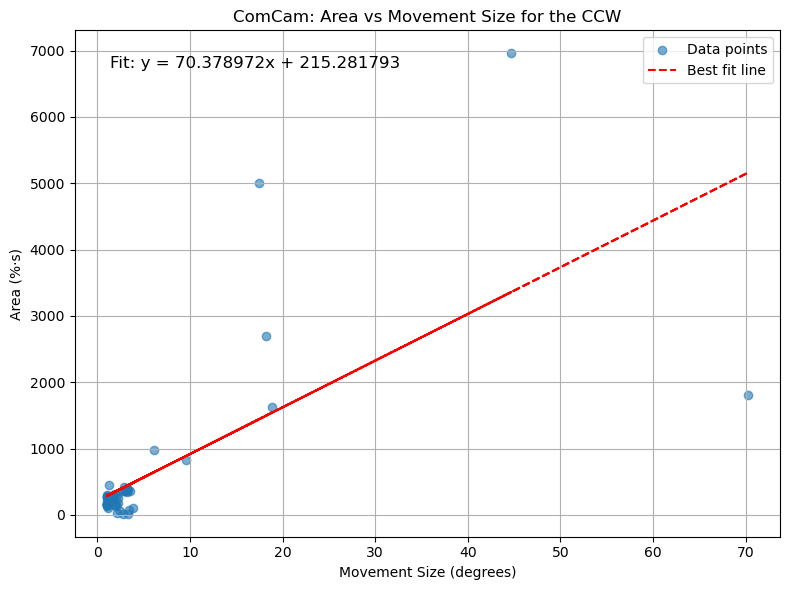

In [41]:
if 'area (% s)' in movement_df.columns and 'movement_size (degrees)' in movement_df.columns:
    x = movement_df['movement_size (degrees)']
    y = movement_df['area (% s)']
    
    # Perform linear regression (best-fit line)
    coefficients = np.polyfit(x, y, 1)  
    poly = np.poly1d(coefficients)

    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, color='C0', alpha=0.6, label='Data points')
    
    plt.plot(x, poly(x), color='red', linestyle='--', label='Best fit line')

    plt.xlabel('Movement Size (degrees)')
    plt.ylabel('Area (%·s)')
    plt.title('ComCam: Area vs Movement Size for the CCW')

    slope = coefficients[0]
    intercept = coefficients[1]
    equation = f'Fit: y = {slope:.6f}x + {intercept:.6f}'

    plt.text(0.05, 0.95, equation, transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', color='black')

    plt.grid(True)

    plt.legend()

    plt.tight_layout()
    plt.show()

else:
    print("Required columns not found in the DataFrame.")


Polinom fit

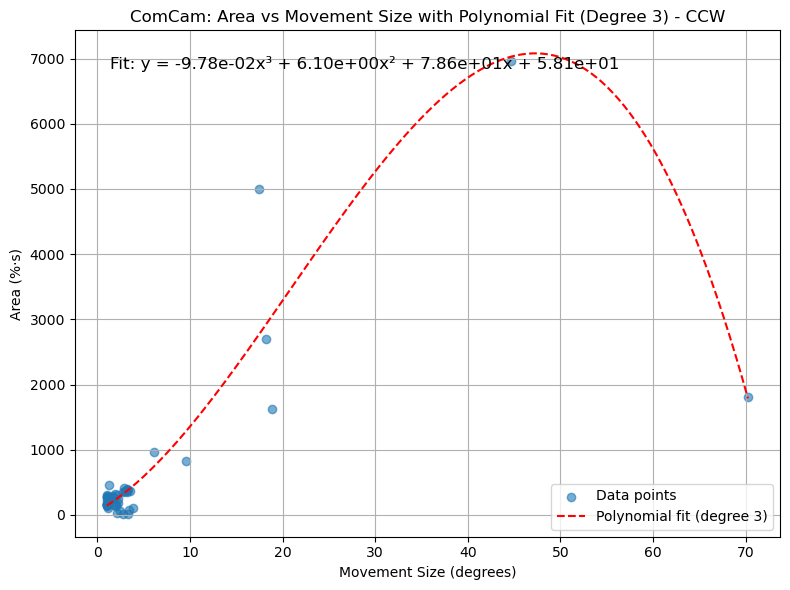

In [42]:
if 'area (% s)' in movement_df.columns and 'movement_size (degrees)' in movement_df.columns:
    x = movement_df['movement_size (degrees)']
    y = movement_df['area (% s)']

    coefficients = np.polyfit(x, y, 3)  
    poly = np.poly1d(coefficients)

    x_fit = np.linspace(x.min(), x.max(), 500)  
    y_fit = poly(x_fit)

    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, color='C0', alpha=0.6, label='Data points')

    plt.plot(x_fit, y_fit, color='red', linestyle='--', label='Polynomial fit (degree 3)')

    plt.xlabel('Movement Size (degrees)')
    plt.ylabel('Area (%·s)')
    plt.title('ComCam: Area vs Movement Size with Polynomial Fit (Degree 3) - CCW')

    equation = f'Fit: y = {coefficients[0]:.2e}x³ + {coefficients[1]:.2e}x² + {coefficients[2]:.2e}x + {coefficients[3]:.2e}'

    plt.text(0.05, 0.95, equation, transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', color='black')

    plt.grid(True)

    plt.legend()

    plt.tight_layout()
    plt.show()

else:
    print("Required columns not found in the DataFrame.")


# Let's try some metrics, like Effitiency ratio: 

This metric tells you how much torque effort (area under the curve) is needed per degree of rotator movement.

Eq: ER=area/movenment size

In [43]:
movement_df["efficiency_ratio"] = movement_df["area (% s)"] / movement_df["movement_size (degrees)"]

In [44]:
print(movement_df["efficiency_ratio"].describe())

count     51.000000
mean     140.381231
std       78.126383
min        6.163701
25%       90.687244
50%      142.695587
75%      164.283517
max      372.293820
Name: efficiency_ratio, dtype: float64


Let's do the histogram. If the values cluster around a specific range, it means most movements require similar torque per degree.

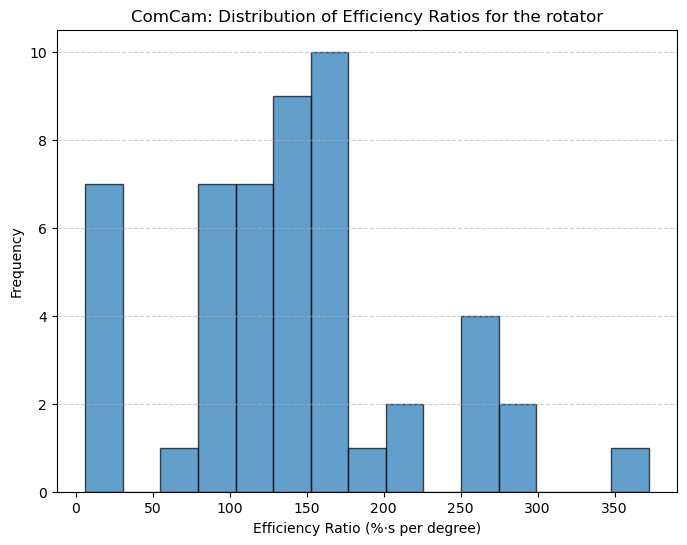

In [45]:
plt.figure(figsize=(8, 6))
plt.hist(movement_df["efficiency_ratio"], bins=15, color="C0", alpha=0.7, edgecolor="black")
plt.xlabel("Efficiency Ratio (%·s per degree)")
plt.ylabel("Frequency")
plt.title("ComCam: Distribution of Efficiency Ratios for the rotator")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

ER VS Movement size. If we see a downward trend, it means larger movements are more efficient (less torque per degree).

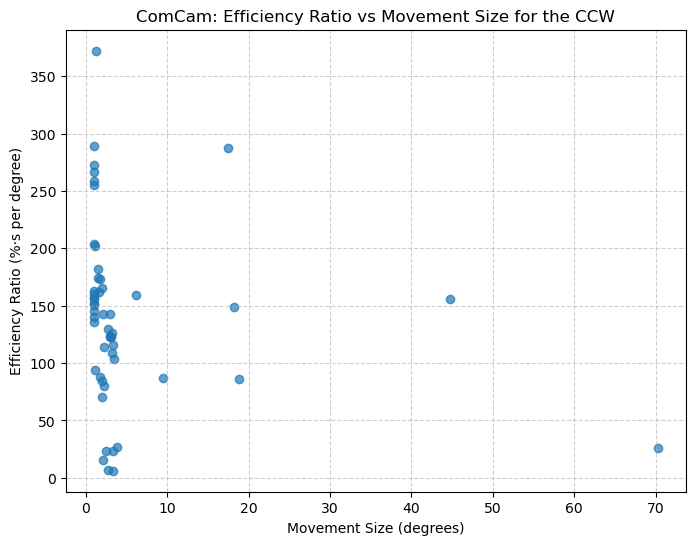

In [46]:
plt.figure(figsize=(8, 6))
plt.scatter(movement_df["movement_size (degrees)"], movement_df["efficiency_ratio"], color="C0", alpha=0.7)
plt.xlabel("Movement Size (degrees)")
plt.ylabel("Efficiency Ratio (%·s per degree)")
plt.title("ComCam: Efficiency Ratio vs Movement Size for the CCW")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()